# Full workflow: external gate plane + band structure + field sweep
This notebook uses the `semiconductor` helpers to apply an external charged plane potential in GPAW, visualize it, compute a band structure along a k-path, and sweep field strengths while saving results after each step for safe interruption/restart.


In [1]:
# Imports
import os
import sys
import csv
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from gpaw import restart

# When running a notebook from inside this folder, import local modules directly
sys.path.insert(0, os.path.abspath('..'))

from external_potentials import ChargedPlanePotential, register_with_gpaw
from gpaw_hooks import apply_external
from analysis import compute_gap, sweep_field_gaps, band_structure_with_path
#from viz import plot_potential_slice, compute_external_grid

# Ensure our custom external potential can be deserialized by GPAW restarts
register_with_gpaw()


In [2]:
# Paths and output setup
gpw_path = '../../gpw/ab.gpw'  # adjust if needed
out_dir = '../../gpw'  # reuse gpw directory for outputs
os.makedirs(out_dir, exist_ok=True)

# Result files for safe interruption
sweep_csv = os.path.join(out_dir, 'field_sweep_results.csv')
log_txt = os.path.join(out_dir, 'field_sweep.log')

def log(msg):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{timestamp}] {msg}'
    print(line)
    with open(log_txt, 'a', encoding='utf-8') as f:
        f.write(line + '\n')


In [3]:
# Load atoms and base calculator
atoms, calc0 = restart(gpw_path)

# Determine z-plane (e.g., 3 Å above the top layer)
z_atoms = atoms.positions[:, 2]
z_plane = float(z_atoms.max() + 3.0)
z_plane


6.35

## Visualize external potential


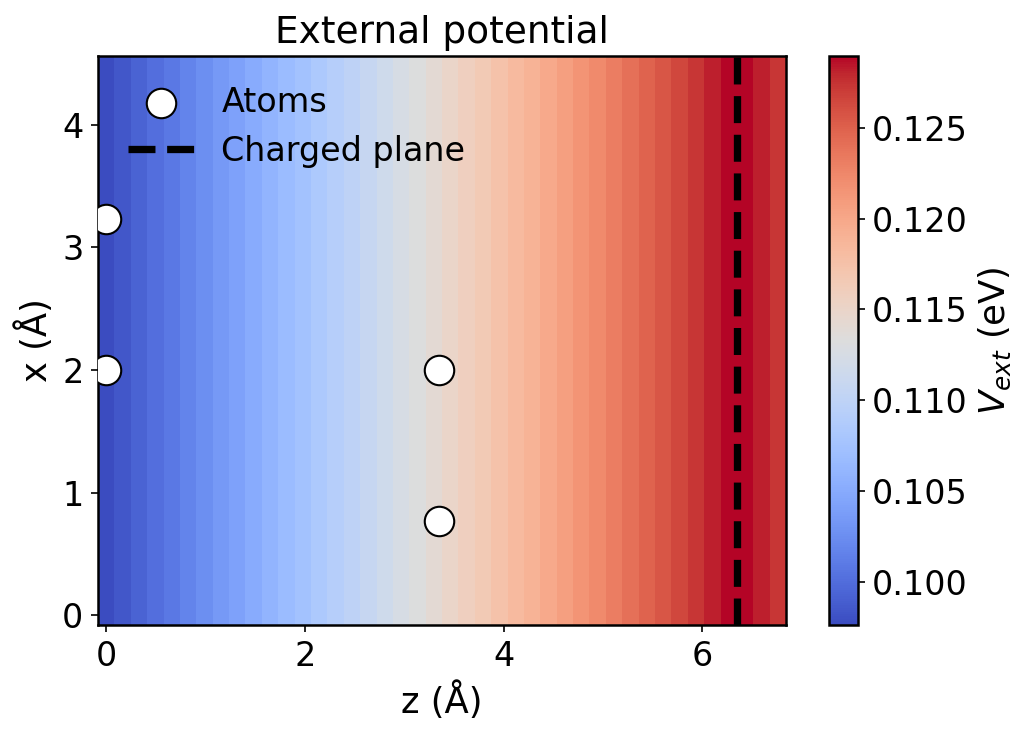

In [4]:
# Choose a small example field strength (A ≈ Ez in eV/Å)
import viz
import importlib
import common
importlib.reload(common)
importlib.reload(viz)

A = 0.005
ext = ChargedPlanePotential(A=A, z_plane=z_plane)

# Visualize the external potential on the GPAW grid
Vext, (x, y, z) = viz.compute_external_grid(calc0, ext, atoms, margin=3.5)
viz.plot_potential_slice(Vext, (x, y, z), atoms)
plt.savefig('../data/external_potential.pdf')
plt.show()


In [8]:
z

array([[[ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        ...,
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ]],

       [[ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        [ 0.        ,  0.16485892,  0.32971784, ..., 62.81124846,
         62.97610738, 63.1409663 ],
        ...,
        [ 0.        ,  0.16485892,  0.32971784, ..., 6

## Apply potential and run SCF (regular)


In [5]:
calc = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.txt'))
atoms.calc = calc
_ = atoms.get_potential_energy()  # triggers a regular SCF with the external potential
gpw_out = os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.gpw')
calc.write(gpw_out)
gpw_out


KeyboardInterrupt: 

## Band structure along a k-path


In [30]:
bs = band_structure_with_path(calc, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
energies = bs.energies[0]
EF = calc.get_fermi_level()
E_shift = energies - EF

plt.figure(figsize=(6, 4))
for n in range(E_shift.shape[1]):
    plt.plot(E_shift[:, n])
plt.ylim(-1, 1)
plt.xlabel('k-path index')
plt.ylabel('Energy (eV)')
plt.title('Bilayer with gate potential')
plt.tight_layout()
plt.show()



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 20:12:32 2025
Arch:   x86_64
Pid:    6974
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.002,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: {npoints: 30,
         pat

KeyboardInterrupt: 

In [7]:
# Define field values (eV/Å)
fields = np.linspace(0, 0.02, 21)

# Load existing results (if any) to enable resume
existing = {}
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                existing[float(row['Ez'])] = float(row['gap'])
            except Exception:
                pass

# Prepare CSV with header if new
new_file = not os.path.exists(sweep_csv)
if new_file:
    with open(sweep_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Ez', 'gap', 'gpw_path'])

results = []
for Ez in fields:
    Ez = float(Ez)
    if Ez in existing:
        log(f'Skipping Ez={Ez:.3f} eV/Å (already in results)')
        results.append((Ez, existing[Ez]))
        continue

    log(f'Running Ez={Ez:.3f} eV/Å')
    ext = ChargedPlanePotential(A=Ez, z_plane=z_plane)
    calcE = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'gate_A{Ez:.3f}.txt'))

    # Trigger a regular SCF with the external potential
    _ = atoms.get_potential_energy()

    # Save calculator state for this field
    gpw_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}.gpw')
    calcE.write(gpw_Ez)

    # Band structure and gap
    bsE = band_structure_with_path(calcE, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
    energies = bsE.energies[0]
    EF = calcE.get_fermi_level()
    E = energies - EF
    gap = float(compute_gap(E))
    results.append((Ez, gap))

    # Append to CSV immediately (interruption-safe)
    with open(sweep_csv, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([f'{Ez:.6f}', f'{gap:.6f}', gpw_Ez])
    log(f'Saved Ez={Ez:.3f}, gap={gap:.4f} eV to CSV and {gpw_Ez}')

# Show summary
for Ez, gap in results:
    print(f'Ez={Ez:.3f} eV/Å -> gap={gap:.4f} eV')

[2025-12-16 19:34:53] Skipping Ez=0.000 eV/Å (already in results)
[2025-12-16 19:34:53] Skipping Ez=0.001 eV/Å (already in results)
[2025-12-16 19:34:53] Running Ez=0.002 eV/Å


KeyboardInterrupt: 

# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [8]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 60           # pool of points before zooming (per full path)
_zoom_label = 'K'                 # special point to zoom around
_zoom_distance = 0.10             # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = True

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    raise Exception('Missing csv file')
    # for _Ez in fields:
    #     _Ez = float(_Ez)
    #     _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
    #     fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 19:36:49 2025
Arch:   x86_64
Pid:    6974
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.00040404040404040404,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: [[ 0.3333

## Field sweep with interruption-safe saving
- Results are appended to a CSV after each field.
- If the CSV already contains an entry for a field value, it will be skipped (resume capability).


# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [26]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 100          # pool of points before zooming (per full path)
_zoom_label = 'K'                # special point to zoom around
_zoom_distance = 0.5            # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = False

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.


[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-16 20:07:37] K-zoom NPZ already exists for Ez=0.002: ..

[2025-12-16 20:10:27] Ez=0.000 -> gap=0.316070 eV


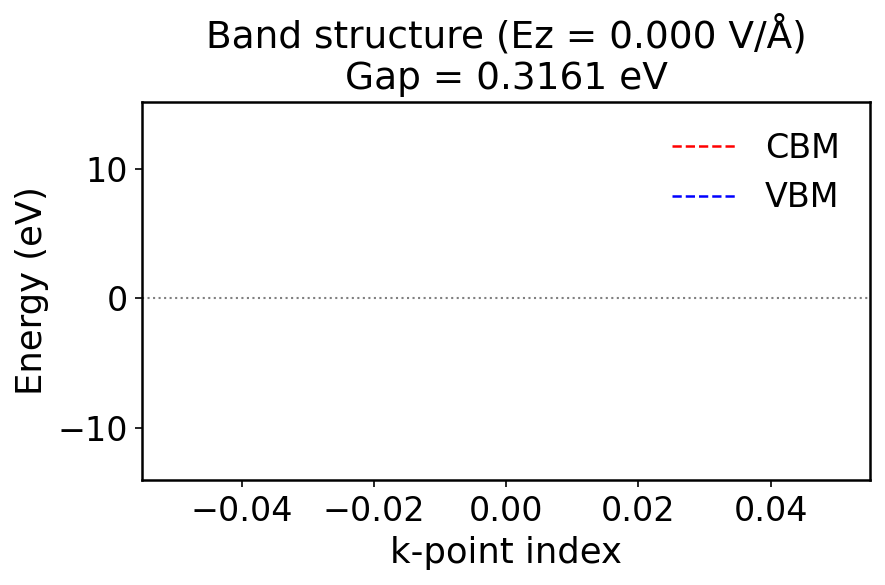

[2025-12-16 20:10:27] Ez=0.000 -> gap=0.316070 eV


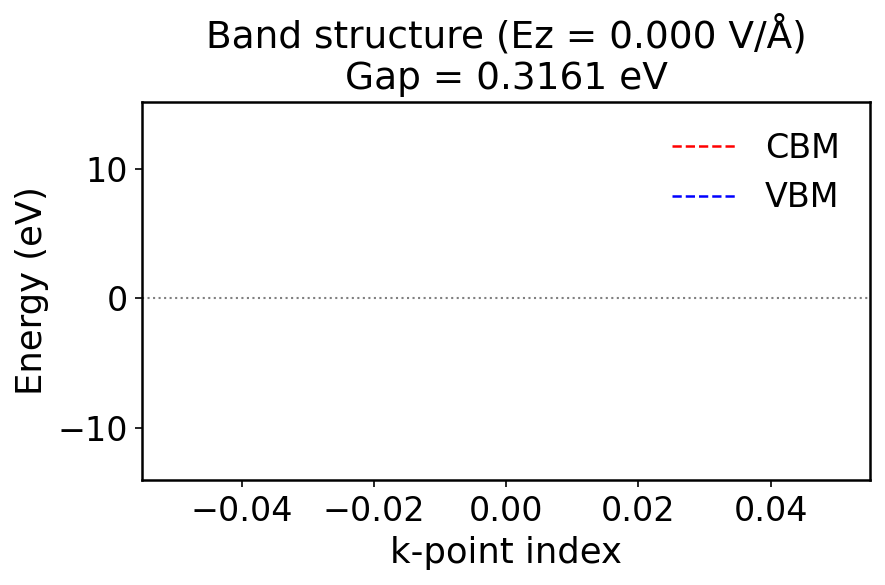

[2025-12-16 20:10:28] Ez=0.001 -> gap=0.175656 eV


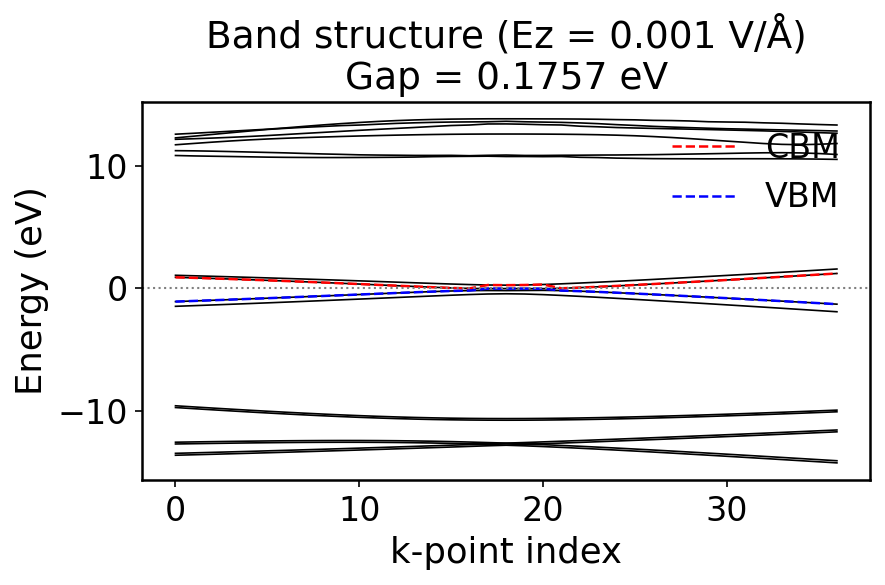

[2025-12-16 20:10:28] Ez=0.001 -> gap=0.175656 eV


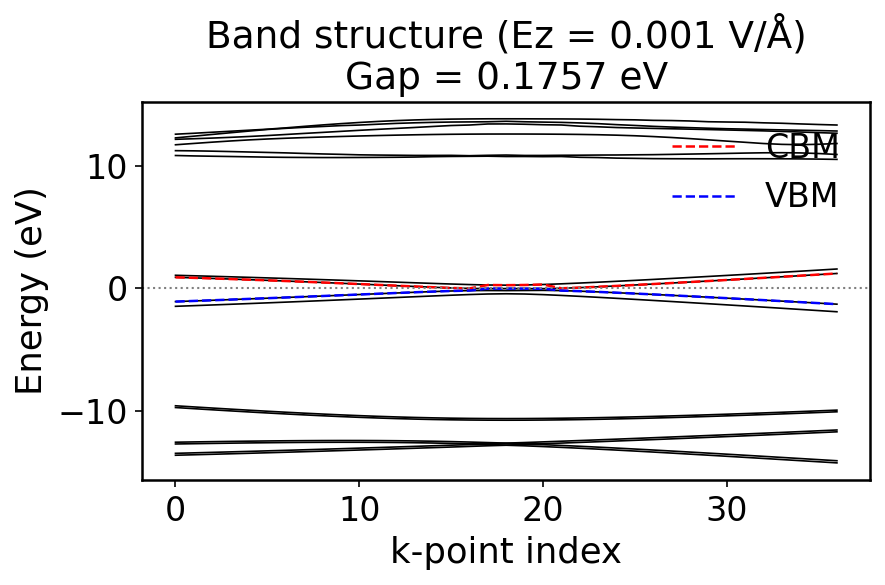

[2025-12-16 20:10:28] Ez=0.001 -> gap=0.175656 eV


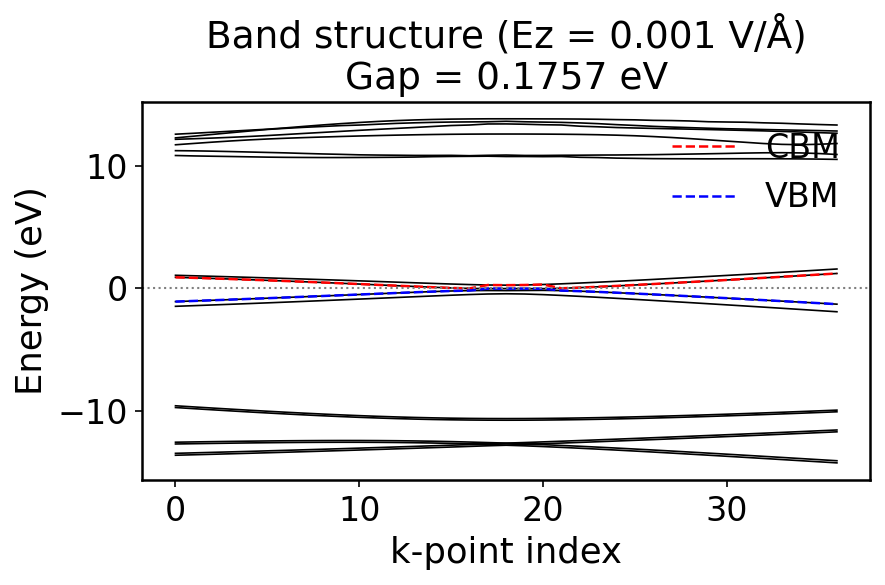

[2025-12-16 20:10:28] Ez=0.001 -> gap=0.175656 eV


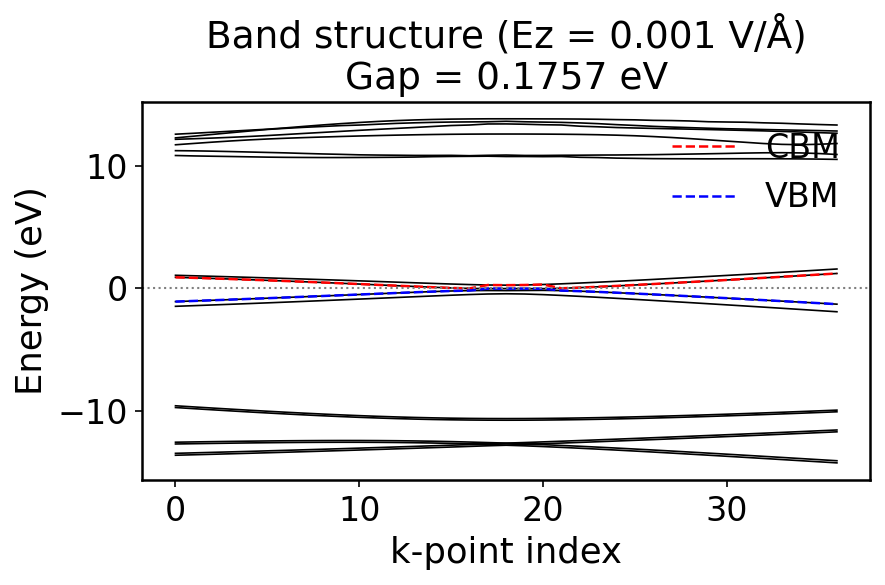

[2025-12-16 20:10:28] Ez=0.001 -> gap=0.175656 eV


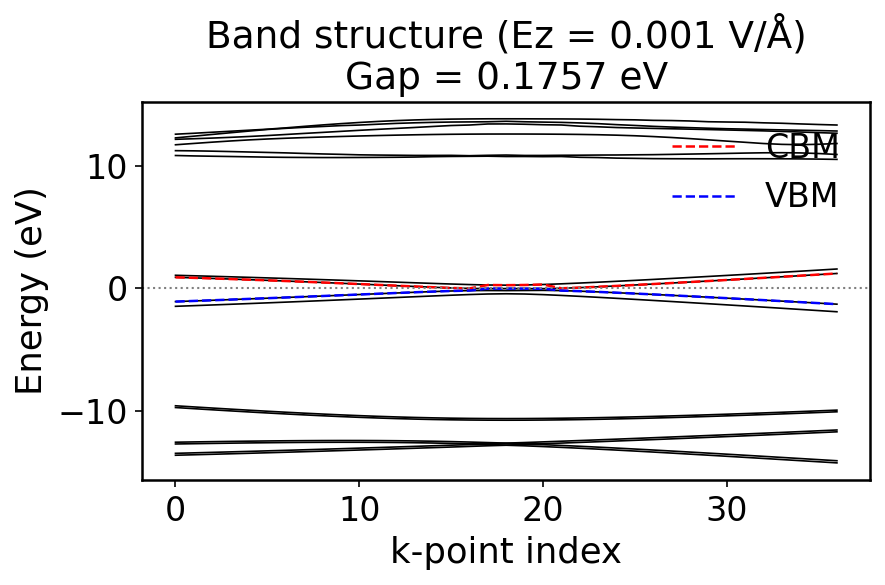

[2025-12-16 20:10:29] Ez=0.001 -> gap=0.175656 eV


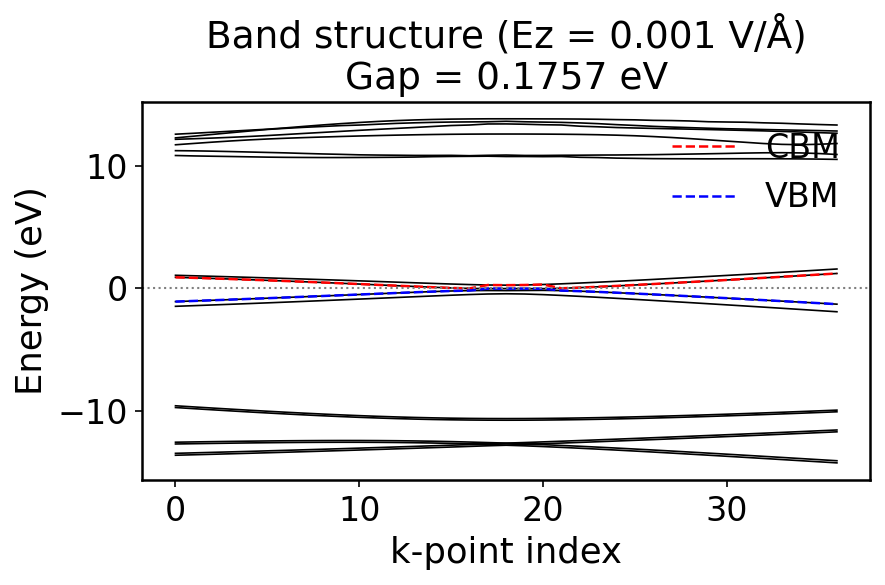

[2025-12-16 20:10:29] Ez=0.002 -> gap=0.399021 eV


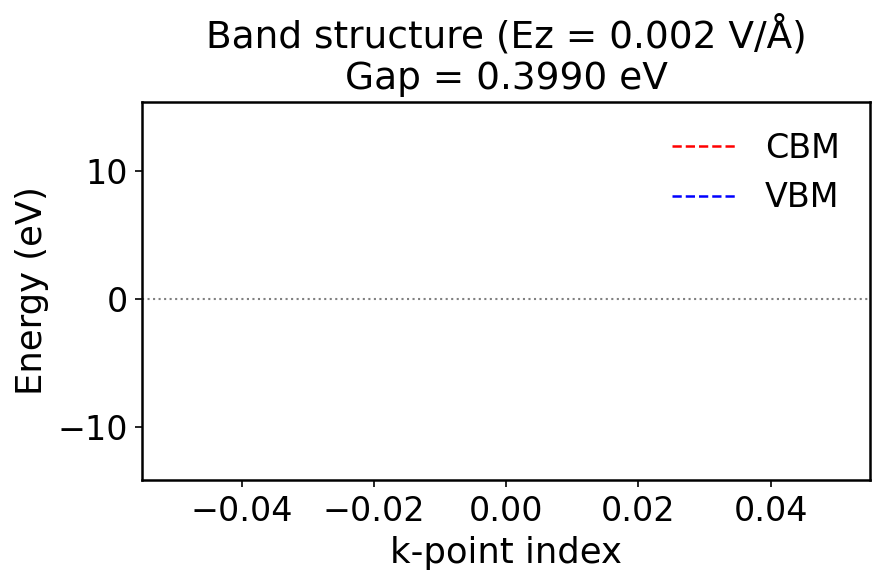

[2025-12-16 20:10:29] Ez=0.002 -> gap=0.399021 eV


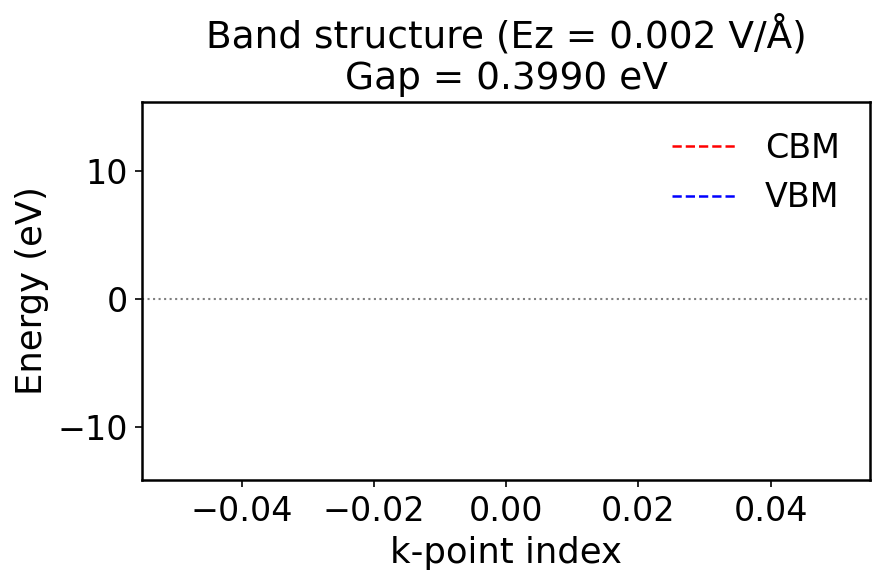

[2025-12-16 20:10:29] Ez=0.002 -> gap=0.399021 eV


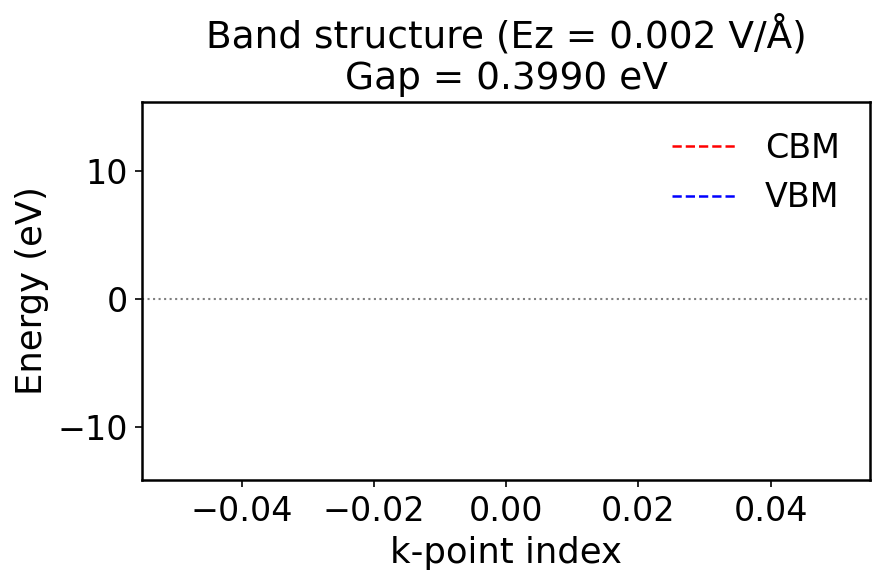

[2025-12-16 20:10:29] Ez=0.002 -> gap=0.399021 eV


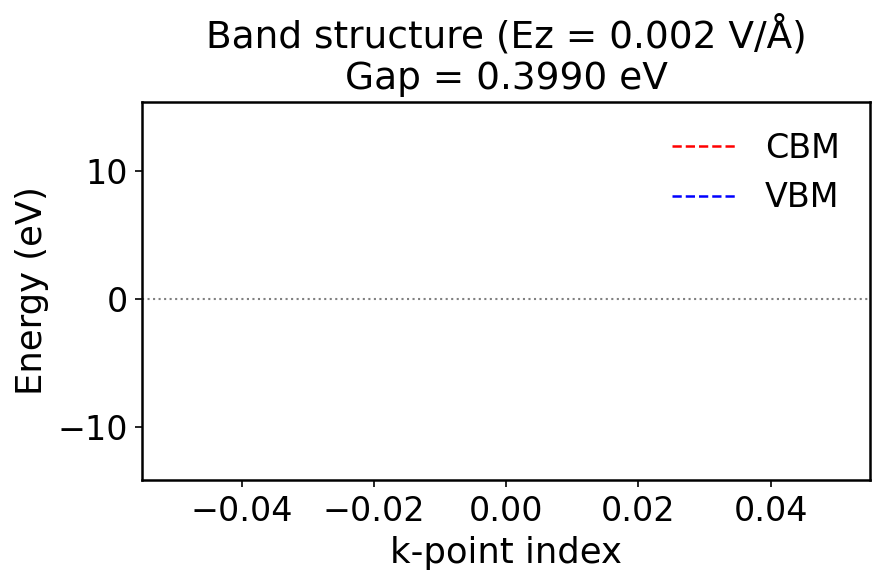

[2025-12-16 20:10:30] Ez=0.002 -> gap=0.399021 eV


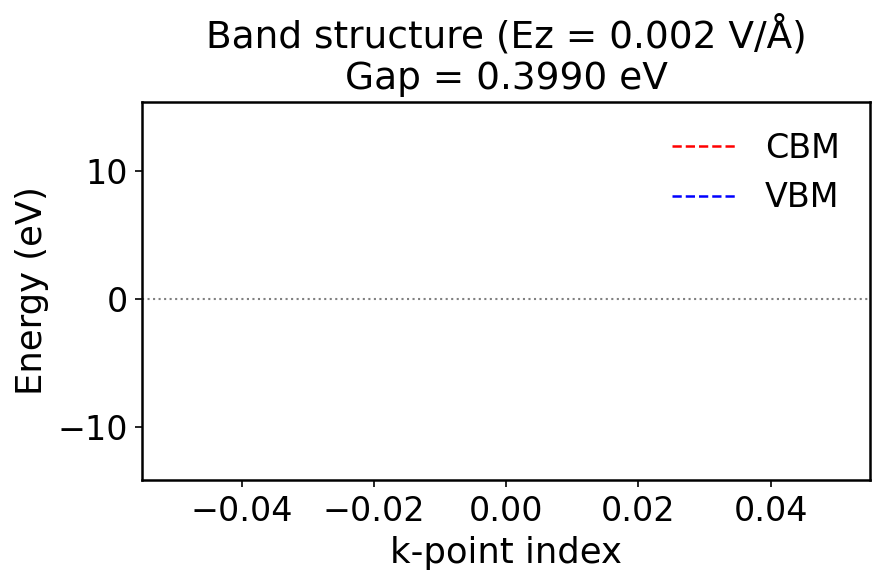

[2025-12-16 20:10:30] Ez=0.003 -> gap=0.517056 eV


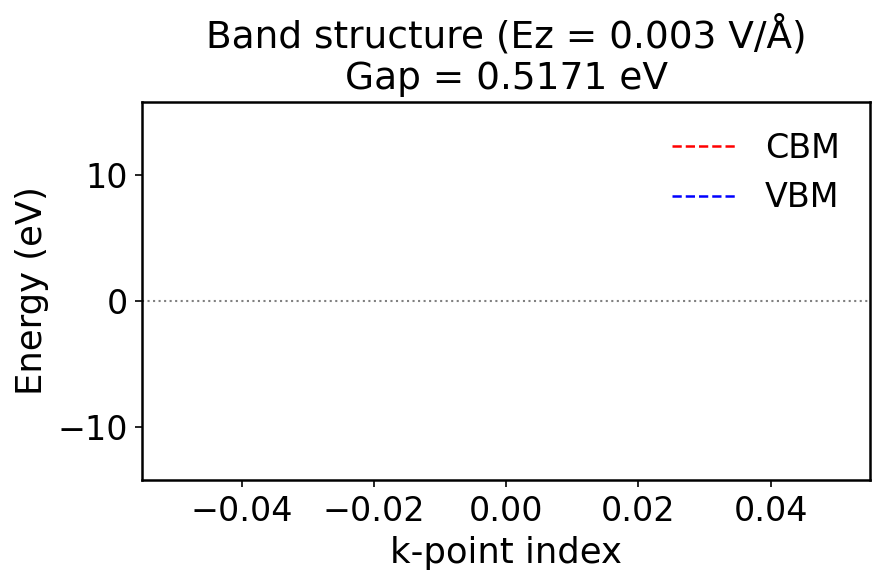

[2025-12-16 20:10:30] Ez=0.003 -> gap=0.517056 eV


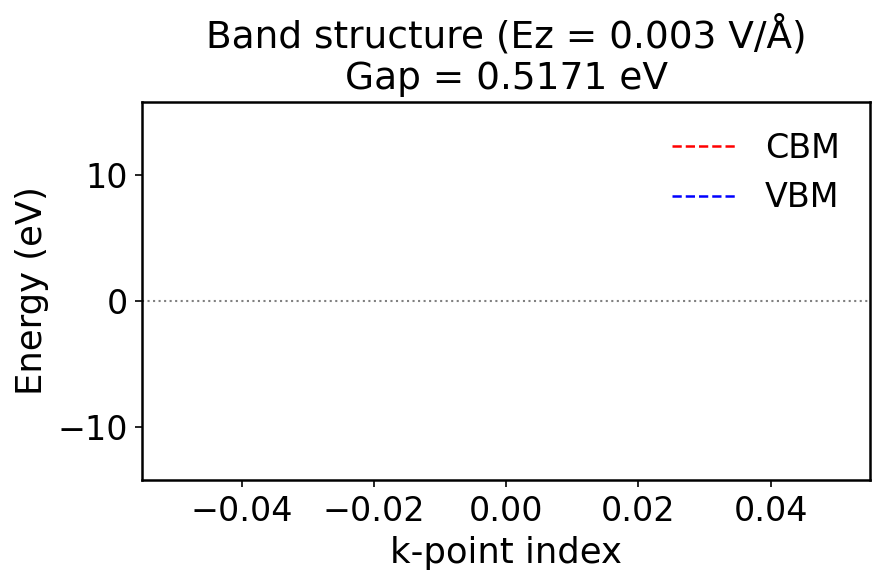

[2025-12-16 20:10:30] Ez=0.003 -> gap=0.517056 eV


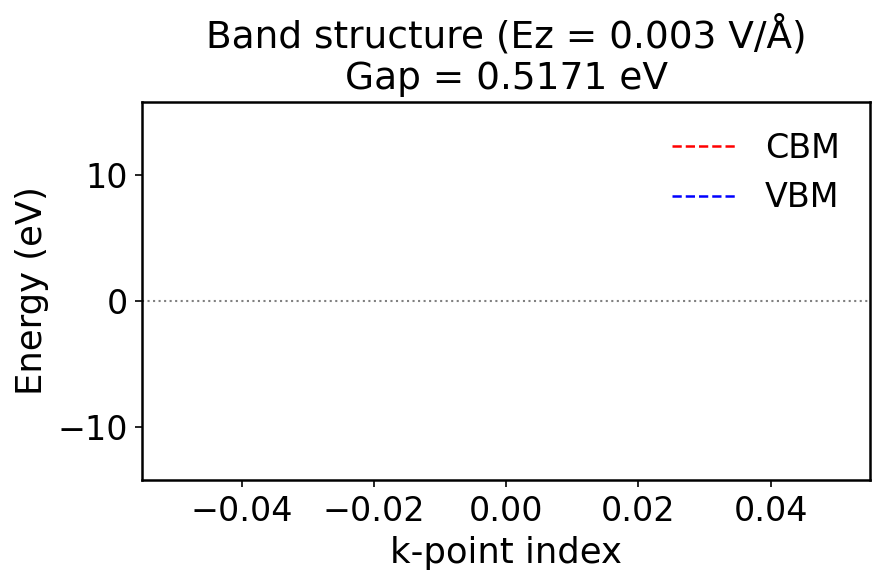

[2025-12-16 20:10:30] Ez=0.003 -> gap=0.517056 eV


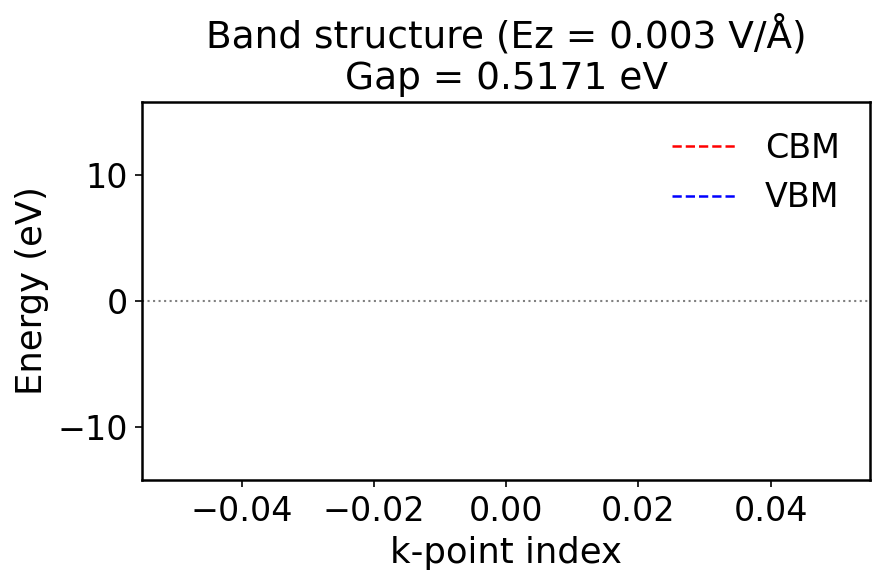

[2025-12-16 20:10:31] Ez=0.003 -> gap=0.517056 eV


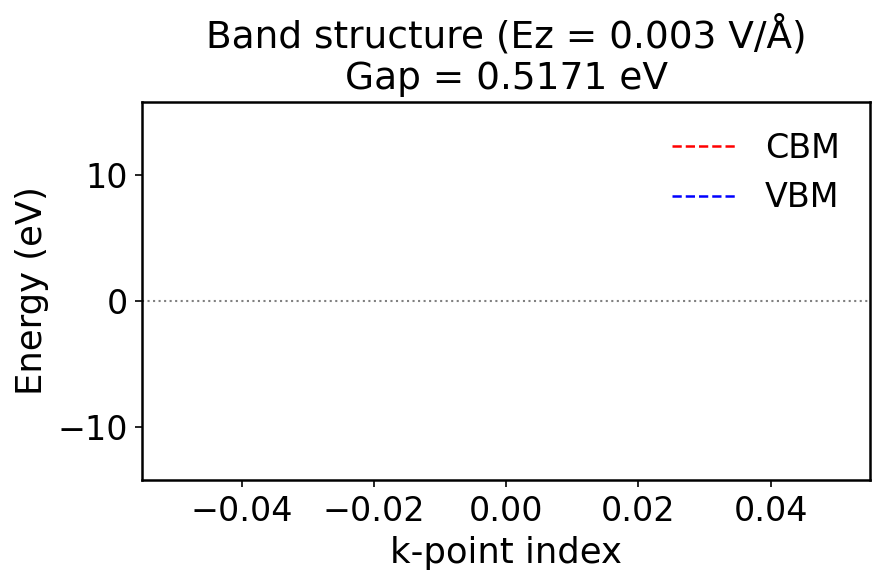

[2025-12-16 20:10:31] Ez=0.003 -> gap=0.517056 eV


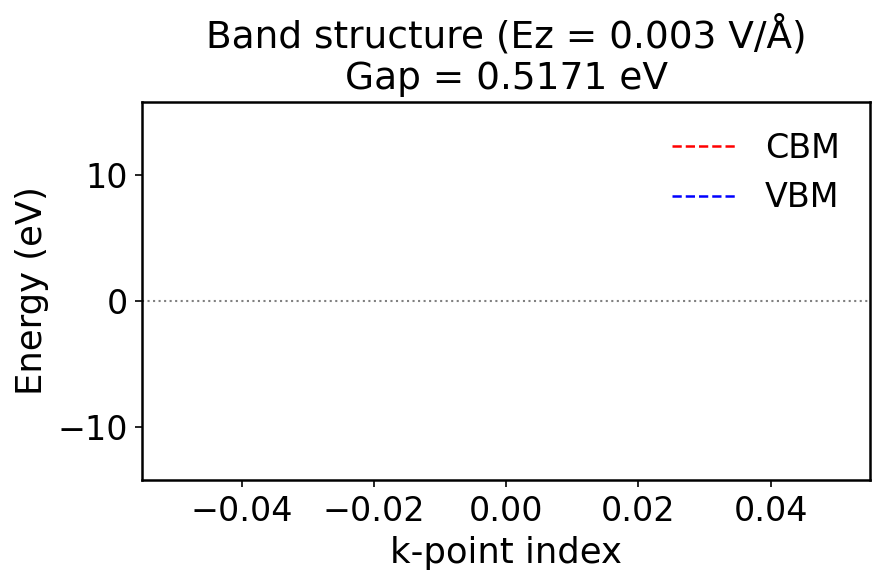

[2025-12-16 20:10:31] Ez=0.004 -> gap=0.634824 eV


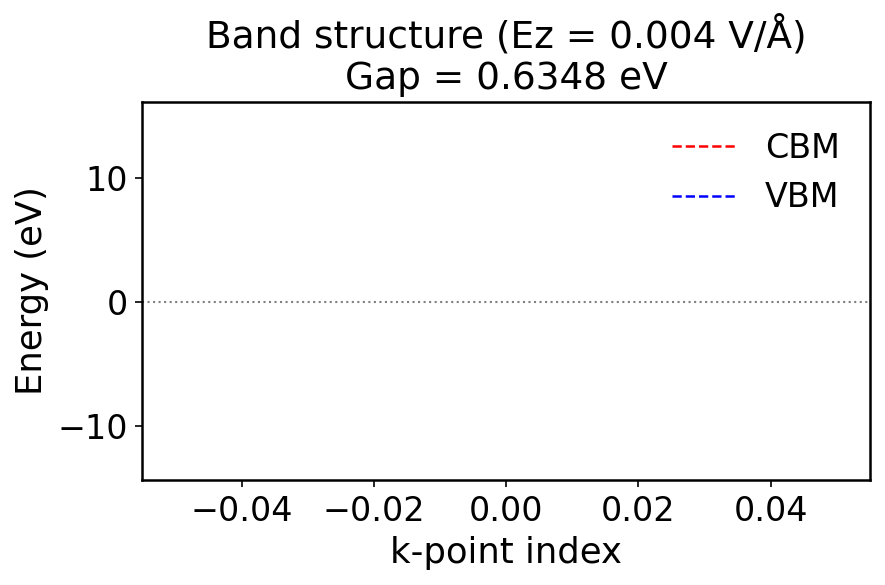

[2025-12-16 20:10:31] Ez=0.004 -> gap=0.634824 eV


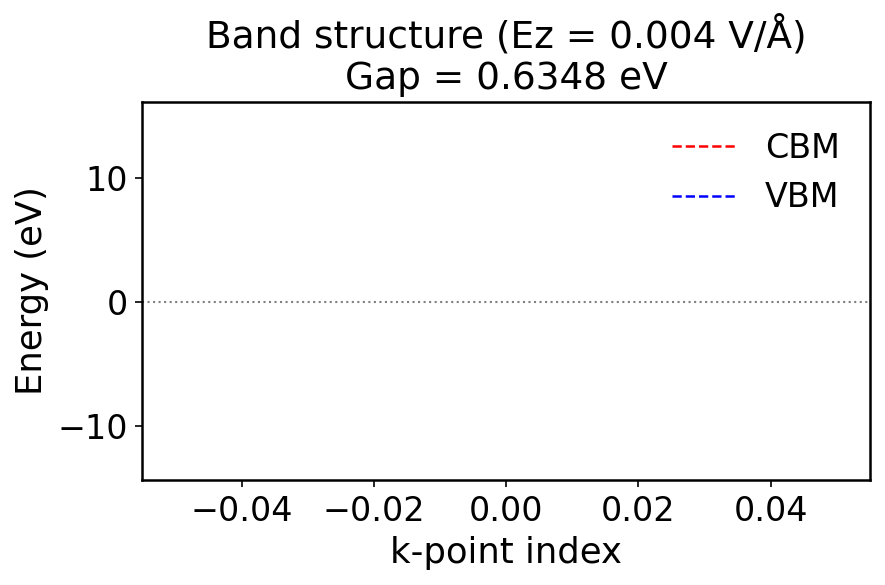

[2025-12-16 20:10:31] Ez=0.004 -> gap=0.634824 eV


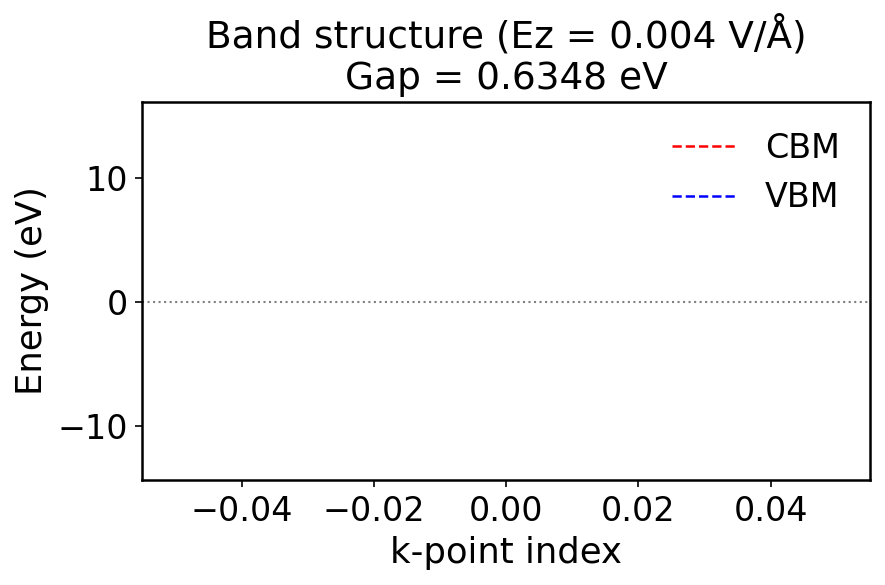

[2025-12-16 20:10:31] Ez=0.004 -> gap=0.634824 eV


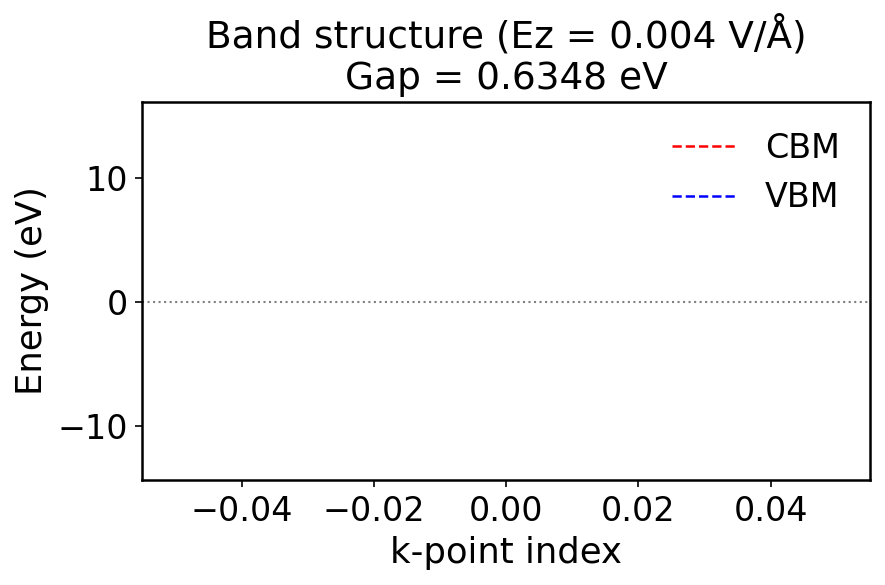

[2025-12-16 20:10:31] Ez=0.004 -> gap=0.634824 eV


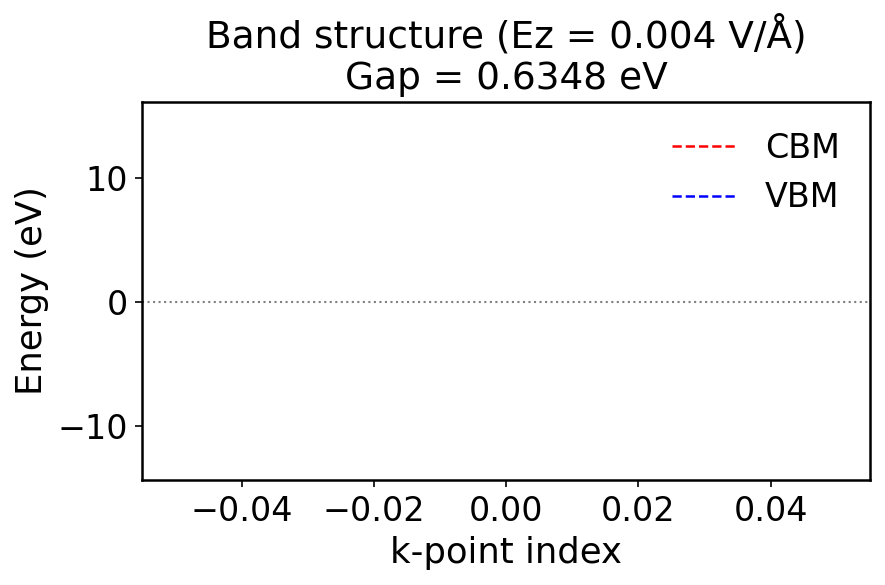

[2025-12-16 20:10:32] Ez=0.005 -> gap=0.716461 eV


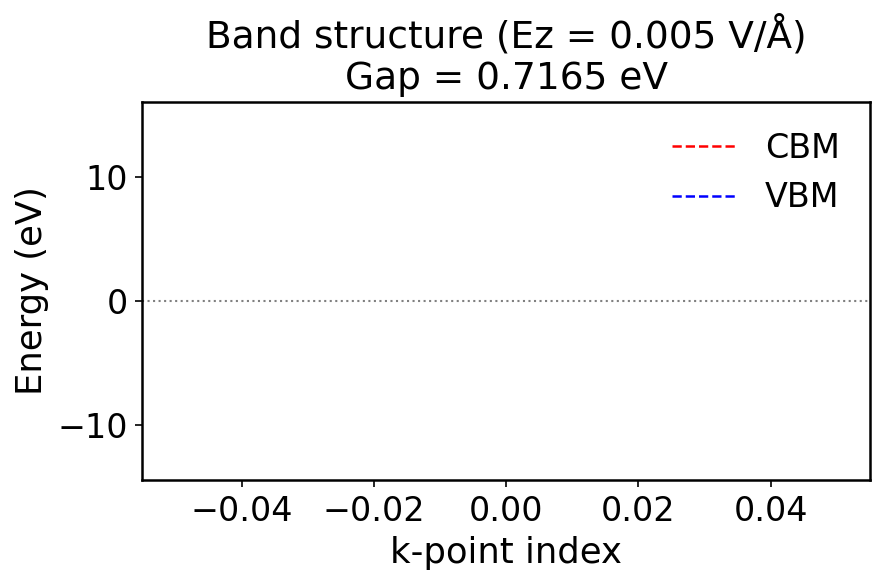

[2025-12-16 20:10:32] Ez=0.005 -> gap=0.716461 eV


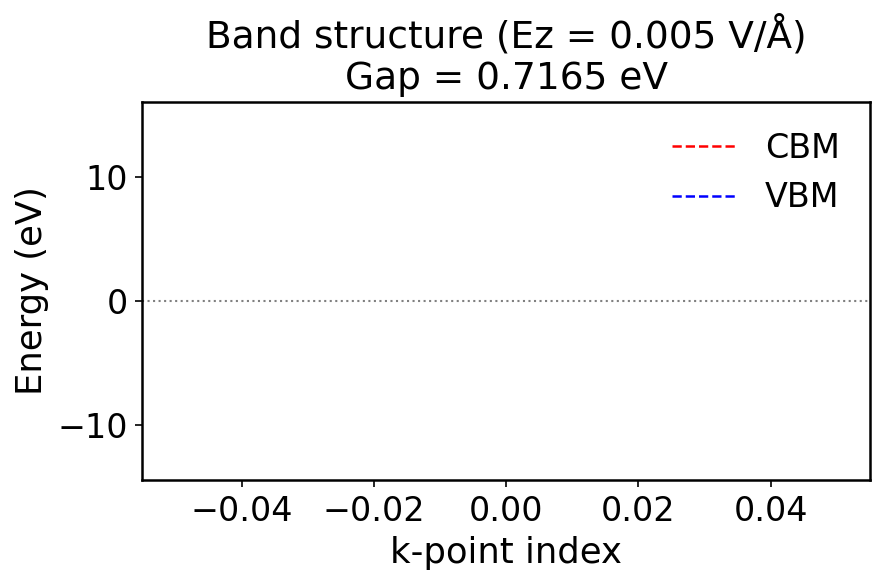

[2025-12-16 20:10:32] Ez=0.005 -> gap=0.716461 eV


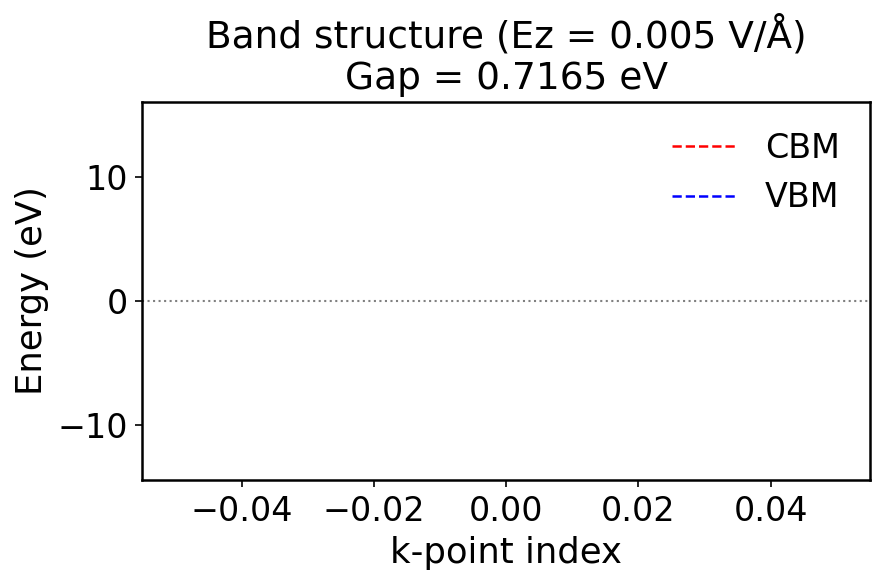

[2025-12-16 20:10:32] Ez=0.005 -> gap=0.716461 eV


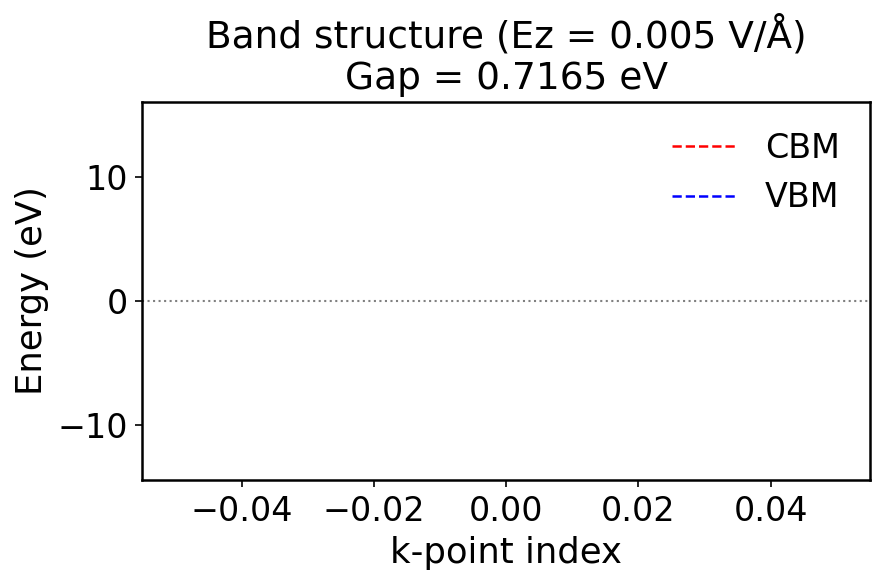

[2025-12-16 20:10:32] Ez=0.005 -> gap=0.716461 eV


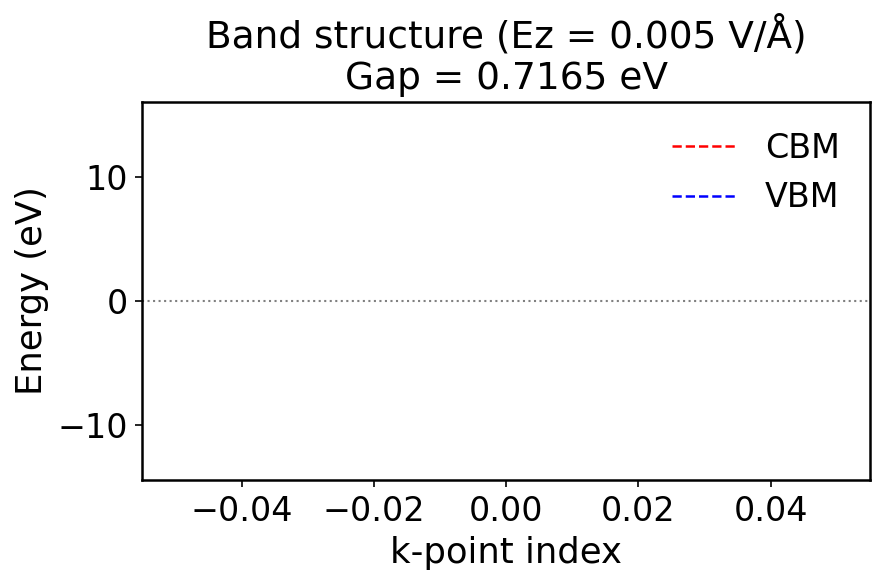

[2025-12-16 20:10:32] Ez=0.006 -> gap=0.791825 eV


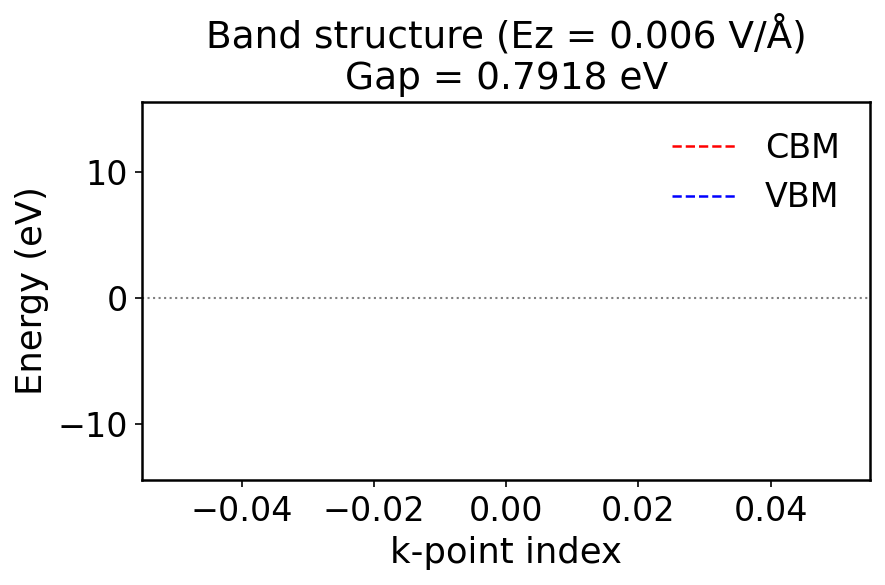

[2025-12-16 20:10:32] Ez=0.006 -> gap=0.791825 eV


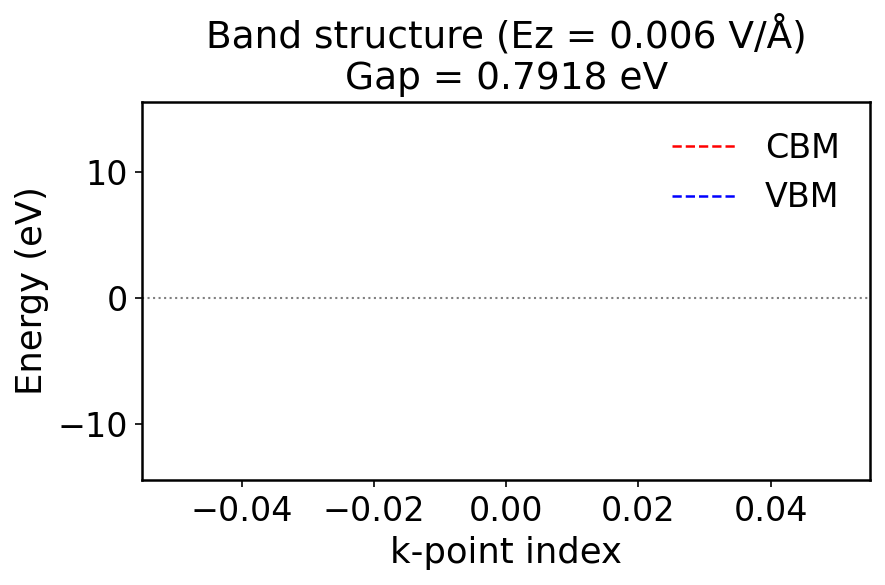

[2025-12-16 20:10:33] Ez=0.006 -> gap=0.791825 eV


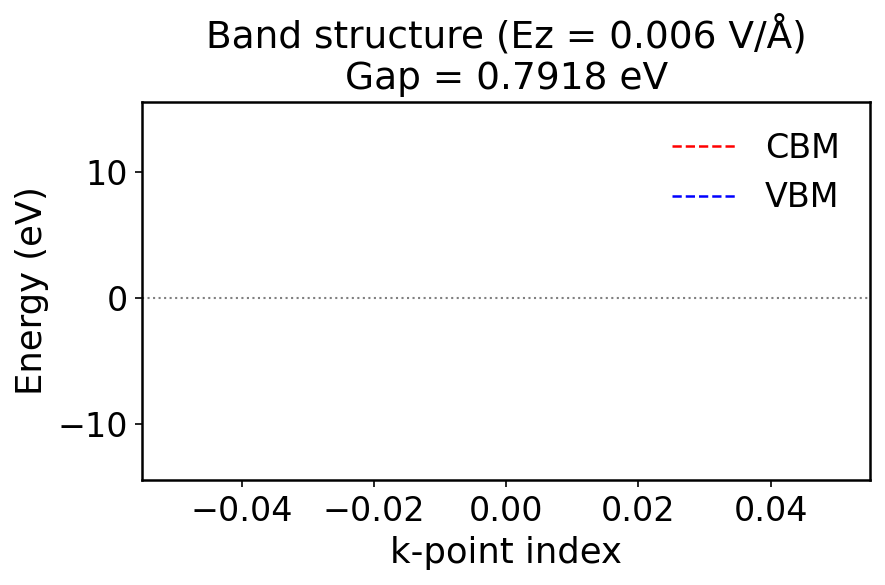

[2025-12-16 20:10:33] Ez=0.006 -> gap=0.791825 eV


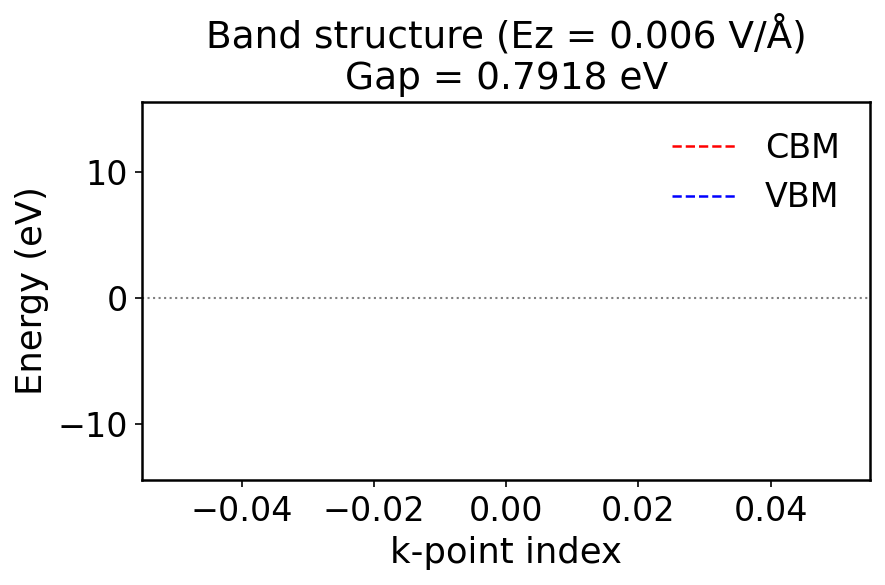

[2025-12-16 20:10:33] Ez=0.006 -> gap=0.791825 eV


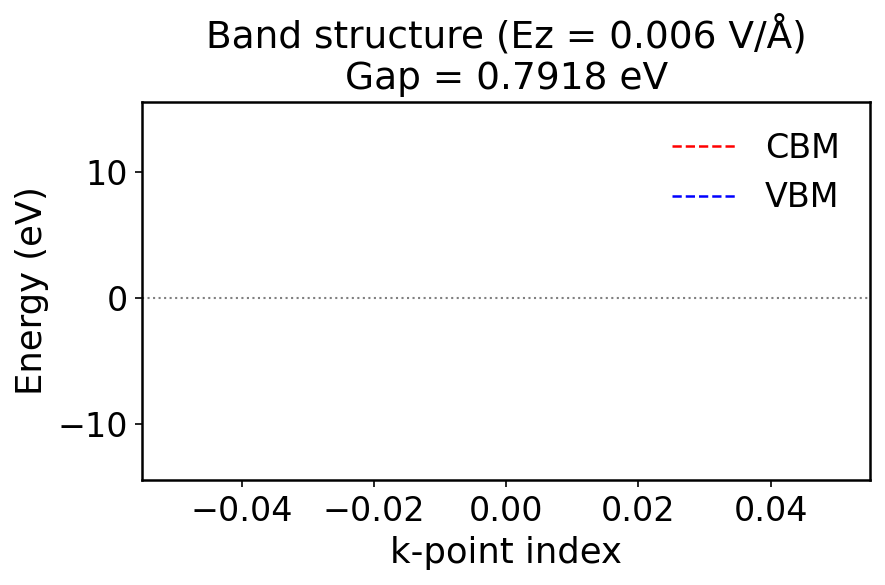

[2025-12-16 20:10:33] Ez=0.007 -> gap=0.807647 eV


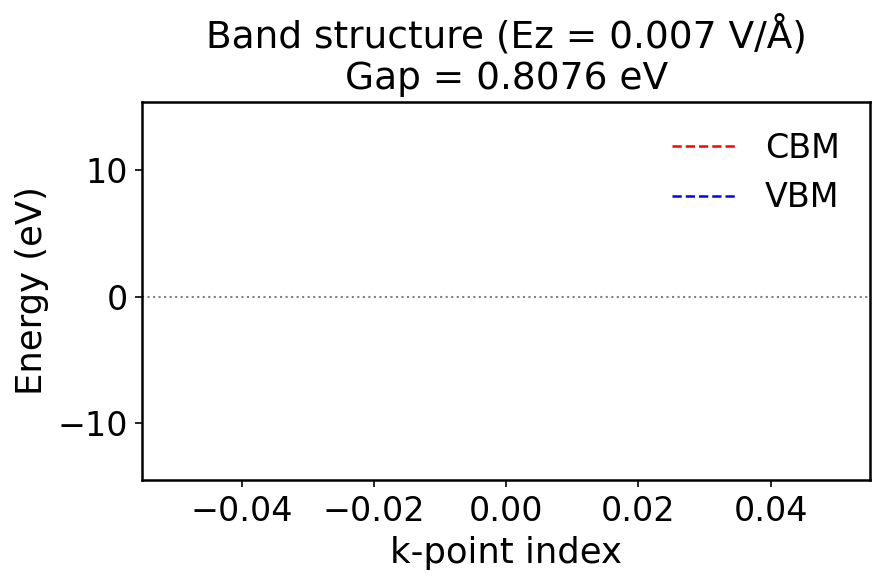

[2025-12-16 20:10:33] Ez=0.007 -> gap=0.807647 eV


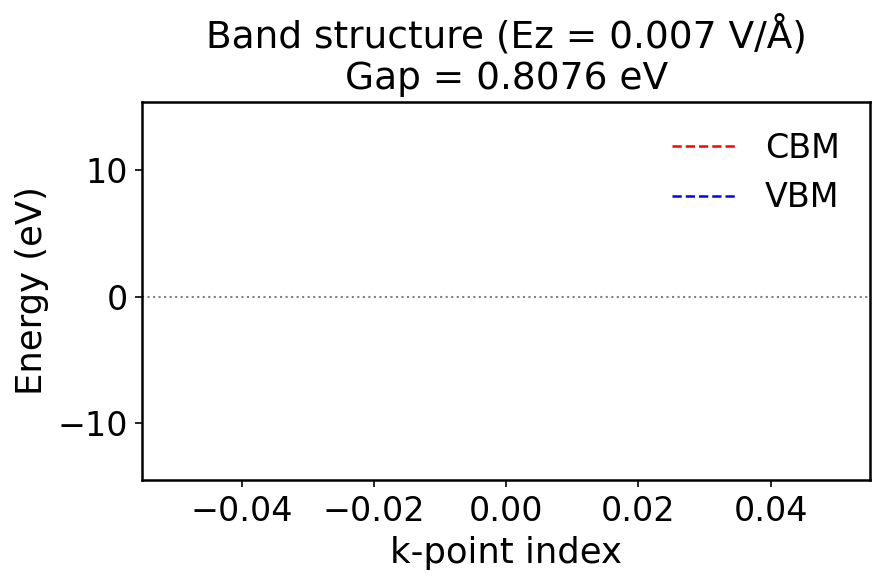

[2025-12-16 20:10:33] Ez=0.007 -> gap=0.807647 eV


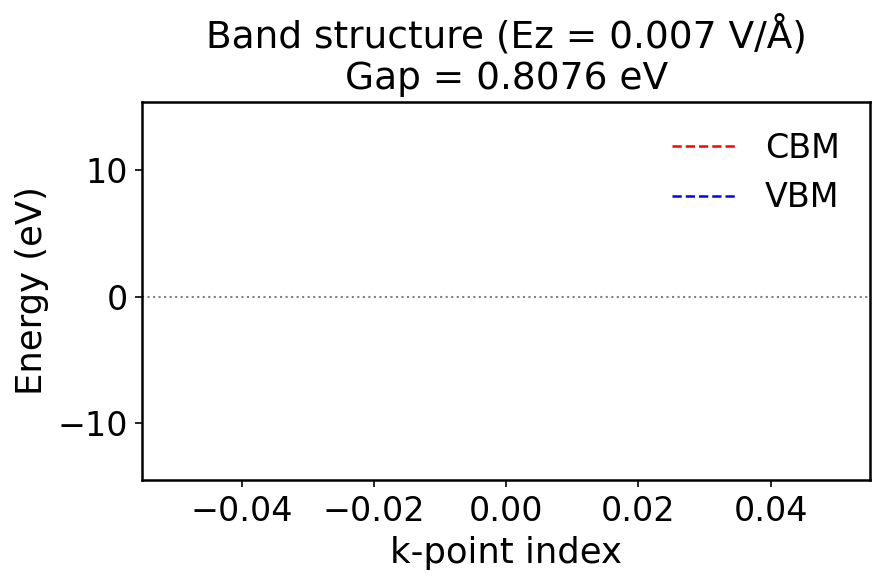

[2025-12-16 20:10:34] Ez=0.007 -> gap=0.807647 eV


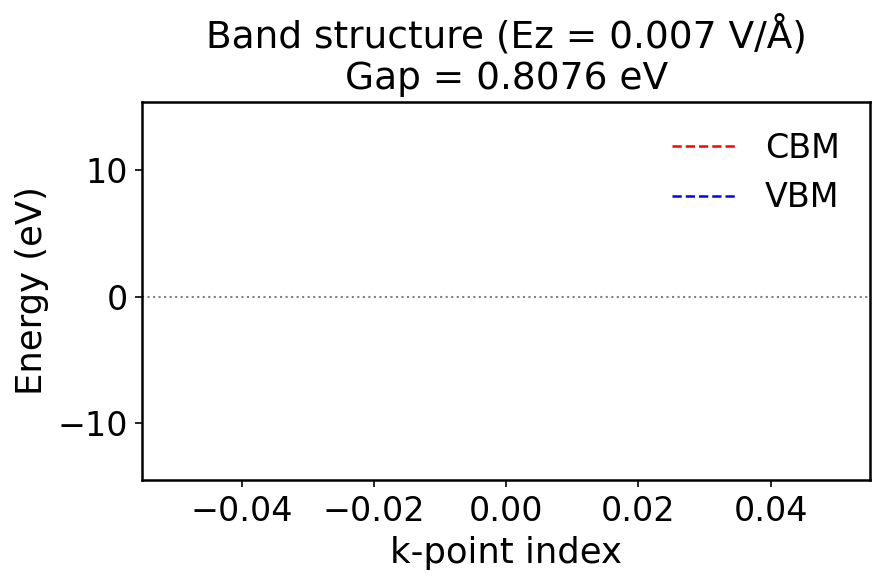

[2025-12-16 20:10:34] Ez=0.007 -> gap=0.807647 eV


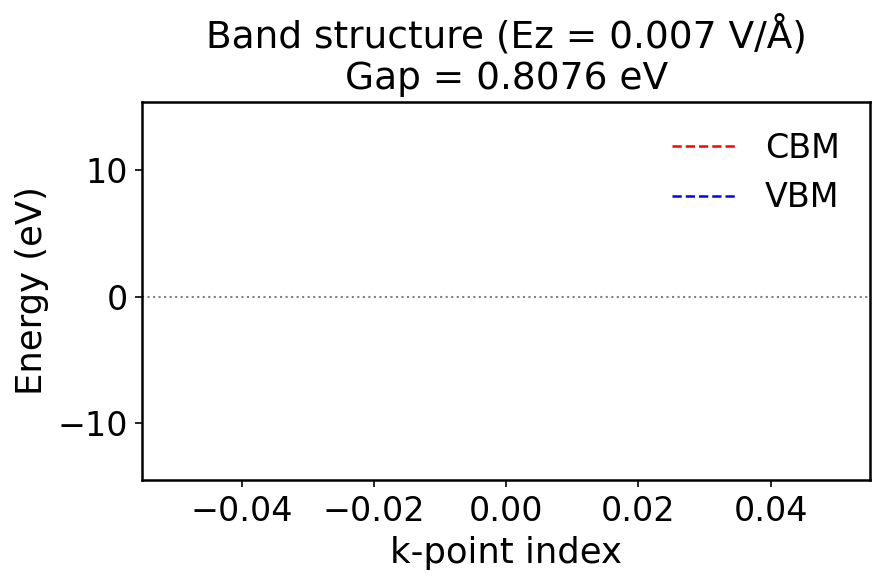

[2025-12-16 20:10:34] Ez=0.007 -> gap=0.807647 eV


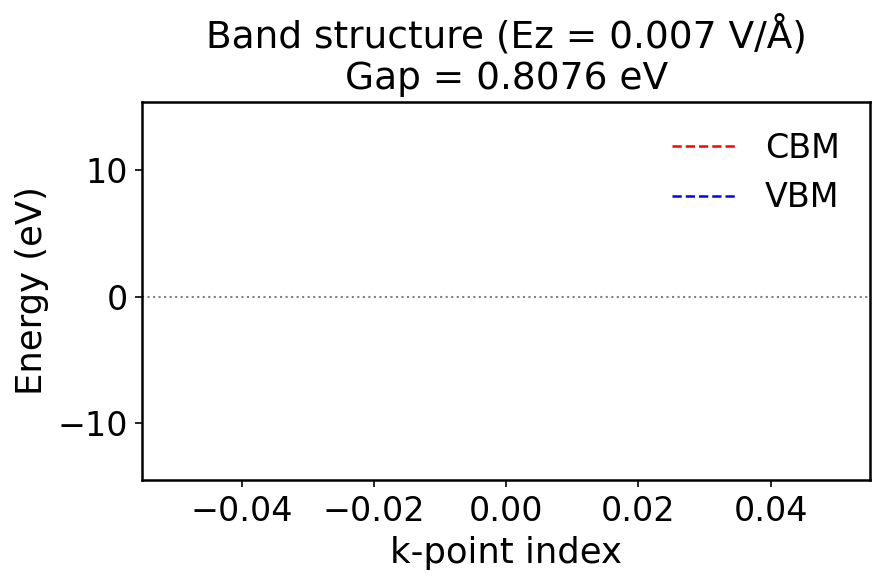

[2025-12-16 20:10:34] Ez=0.008 -> gap=0.934626 eV


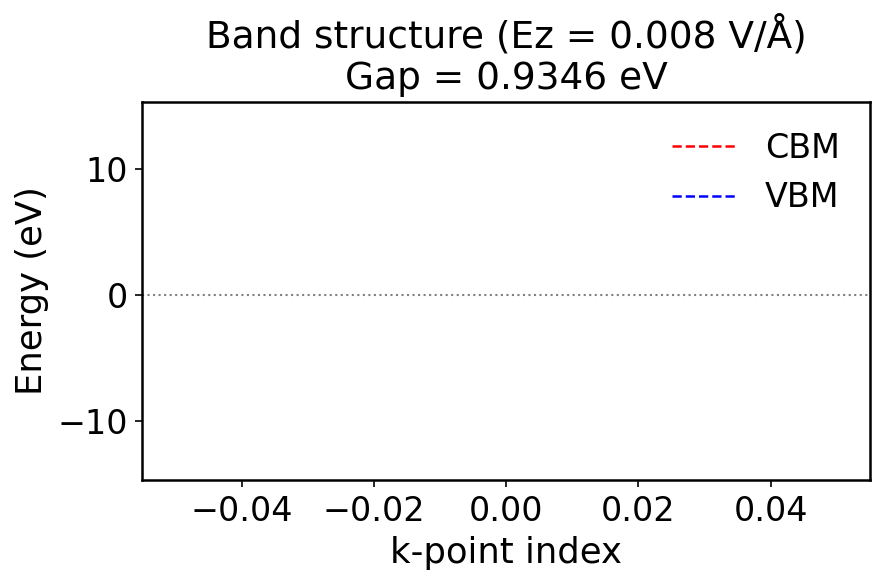

[2025-12-16 20:10:34] Ez=0.008 -> gap=0.934626 eV


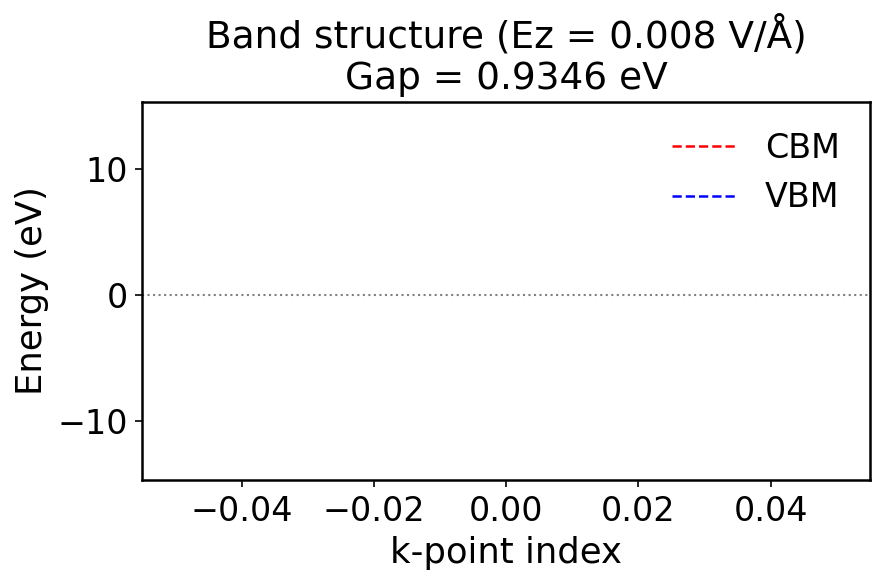

[2025-12-16 20:10:34] Ez=0.008 -> gap=0.934626 eV


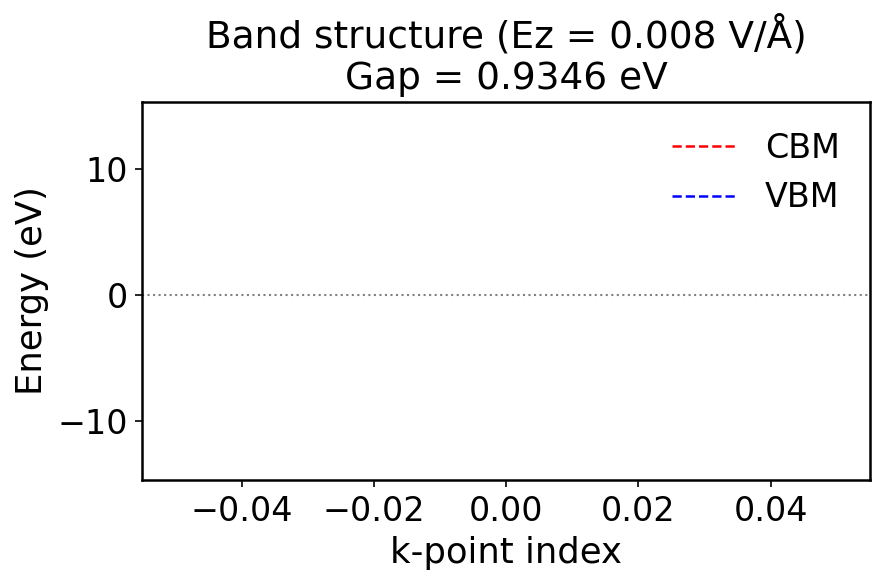

[2025-12-16 20:10:34] Ez=0.008 -> gap=0.934626 eV


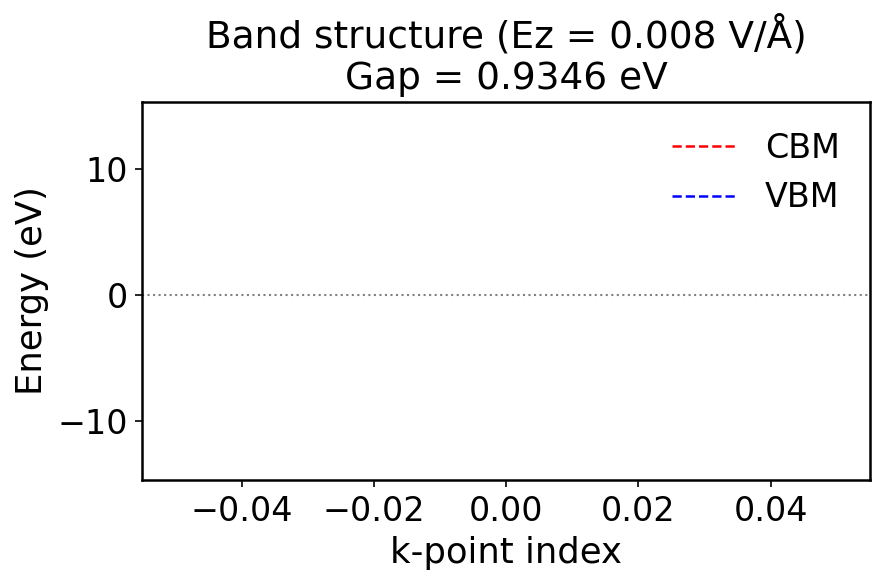

[2025-12-16 20:10:35] Ez=0.008 -> gap=0.934626 eV


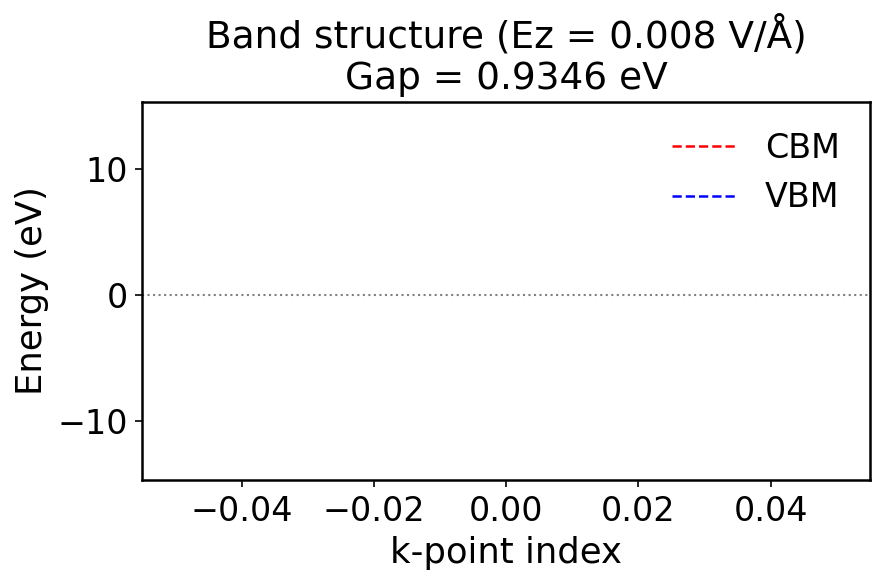

[2025-12-16 20:10:35] Ez=0.009 -> gap=1.000649 eV


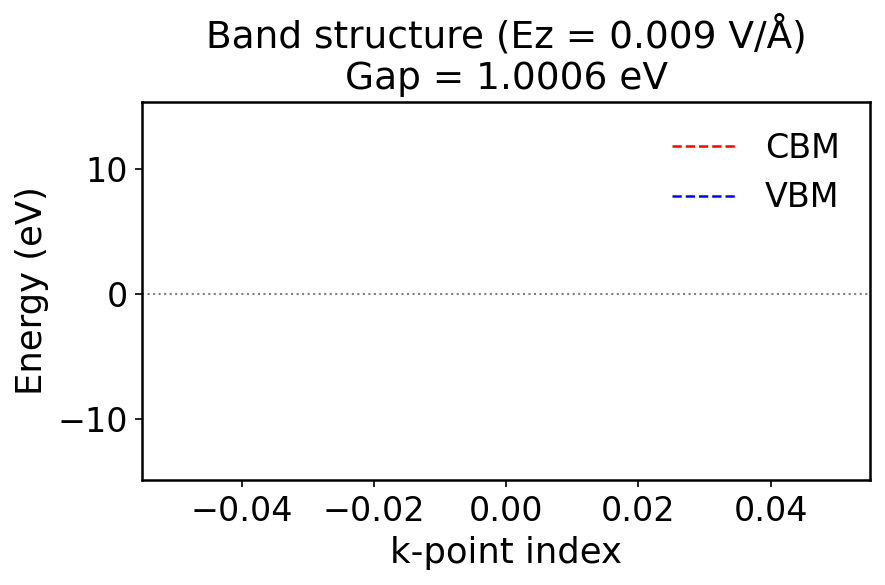

[2025-12-16 20:10:35] Ez=0.009 -> gap=1.000649 eV


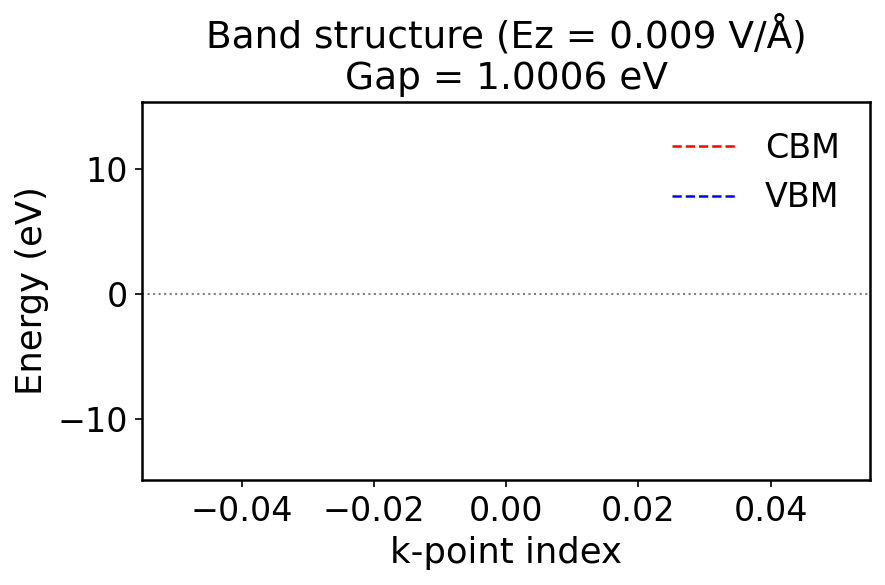

[2025-12-16 20:10:35] Ez=0.009 -> gap=1.000649 eV


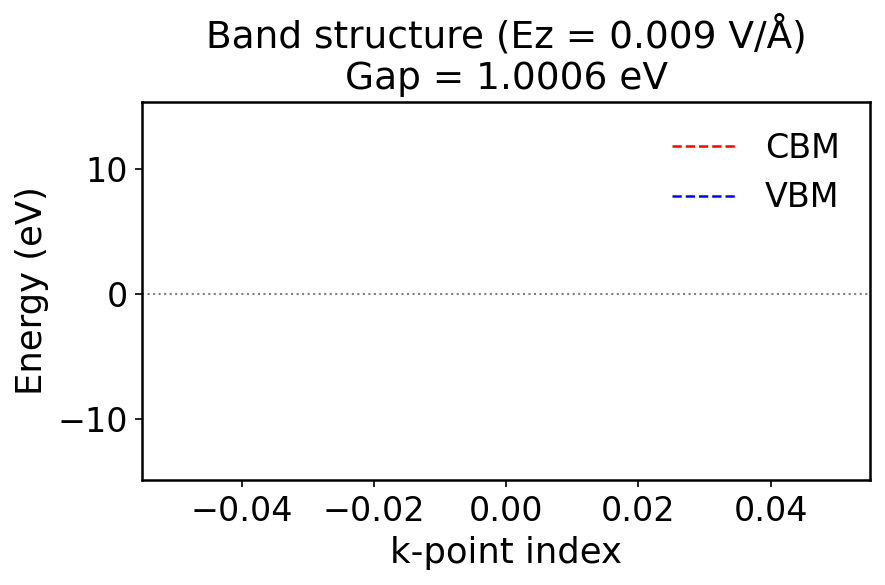

[2025-12-16 20:10:35] Ez=0.009 -> gap=1.000649 eV


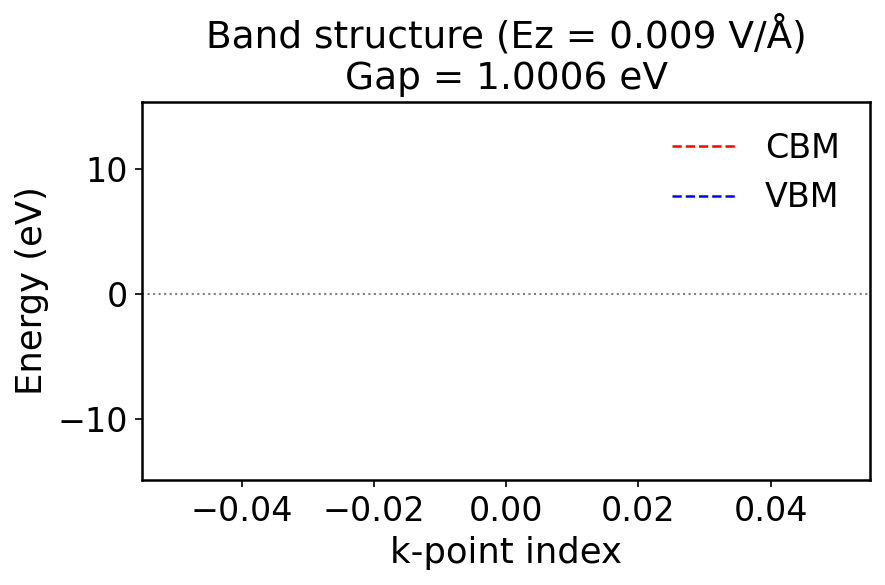

[2025-12-16 20:10:35] Ez=0.009 -> gap=1.000649 eV


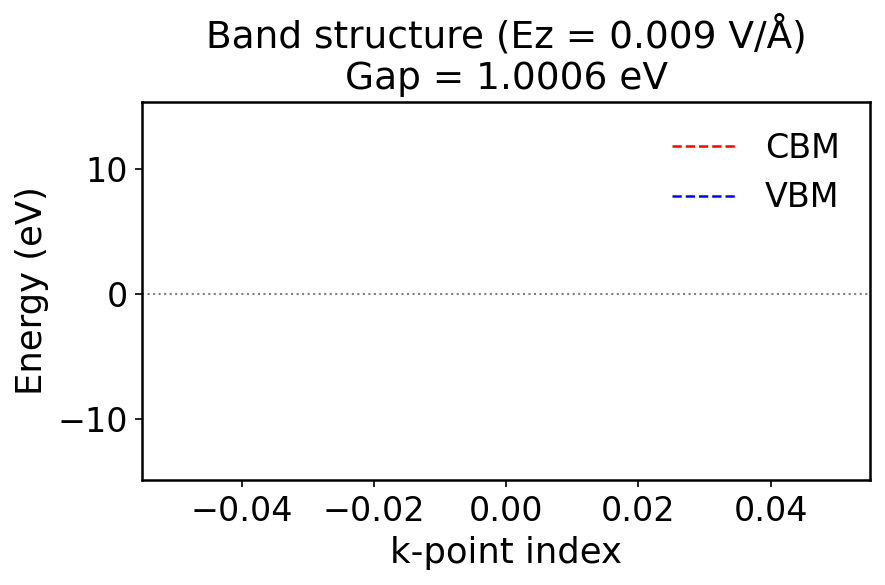

[2025-12-16 20:10:36] Ez=0.010 -> gap=1.037760 eV


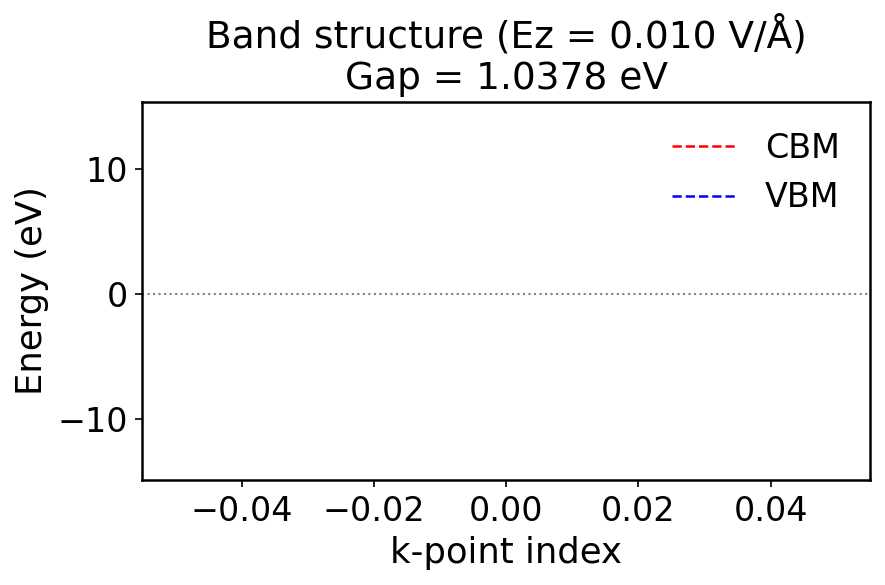

[2025-12-16 20:10:36] Ez=0.010 -> gap=1.037760 eV


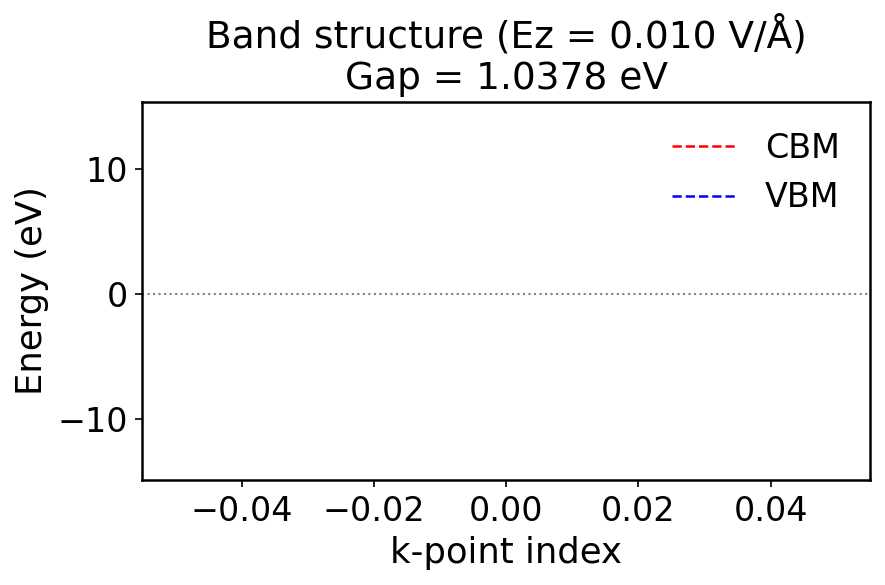

[2025-12-16 20:10:36] Ez=0.010 -> gap=1.037760 eV


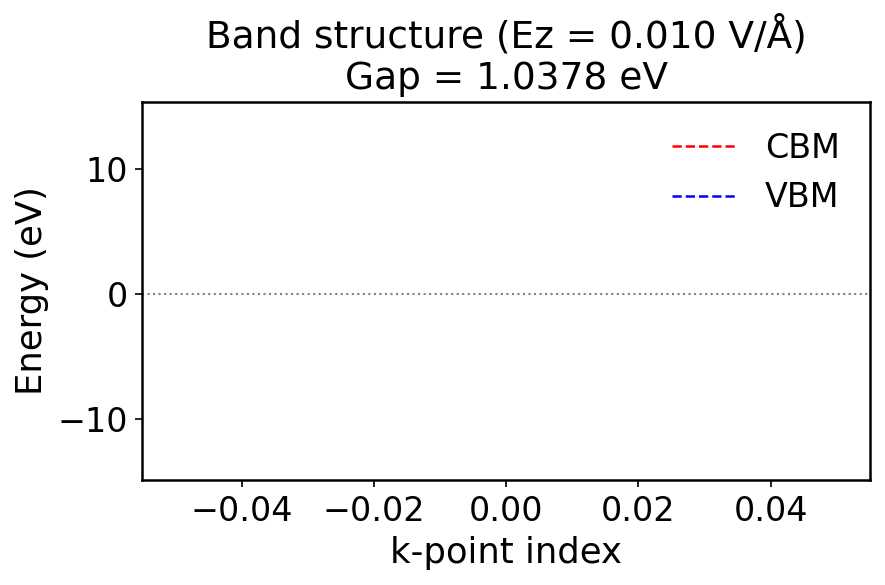

[2025-12-16 20:10:36] Ez=0.010 -> gap=1.037760 eV


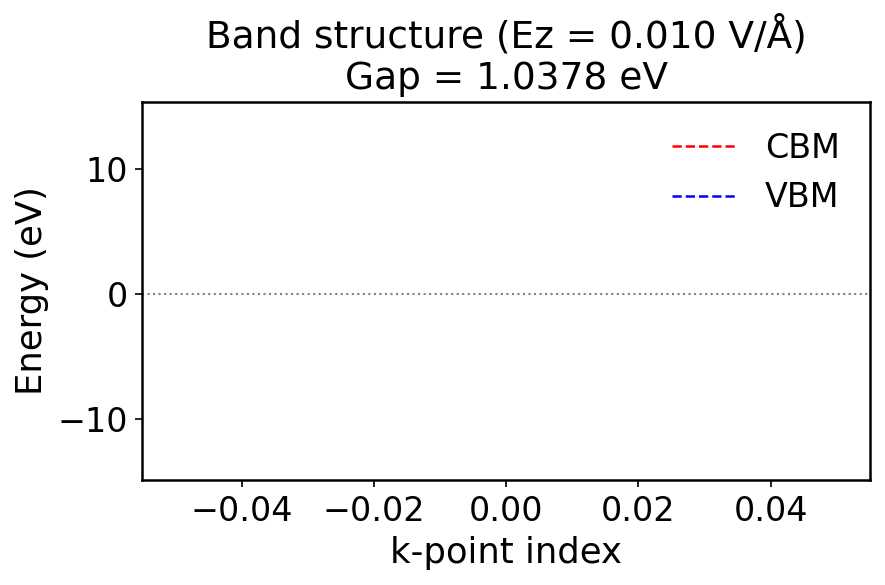

[2025-12-16 20:10:36] Ez=0.010 -> gap=1.037760 eV


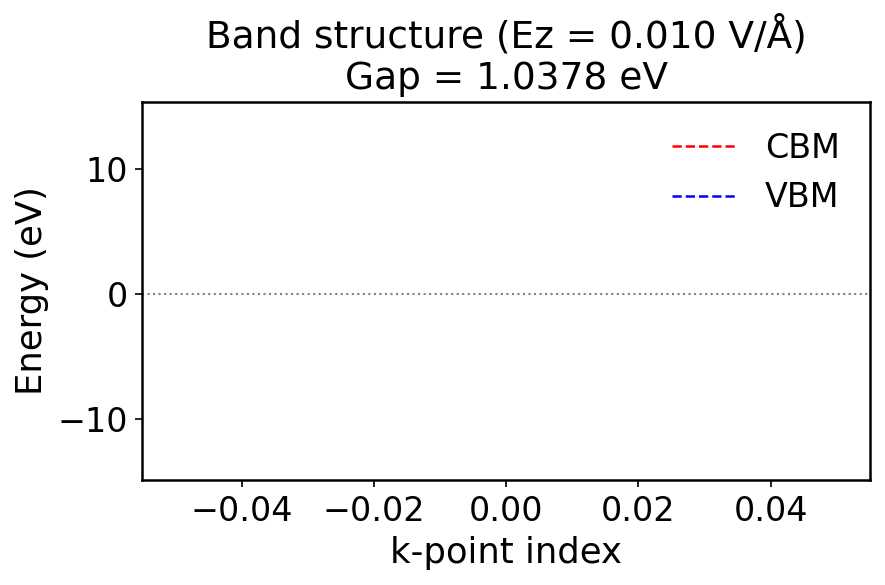

[2025-12-16 20:10:36] Ez=0.011 -> gap=1.114527 eV


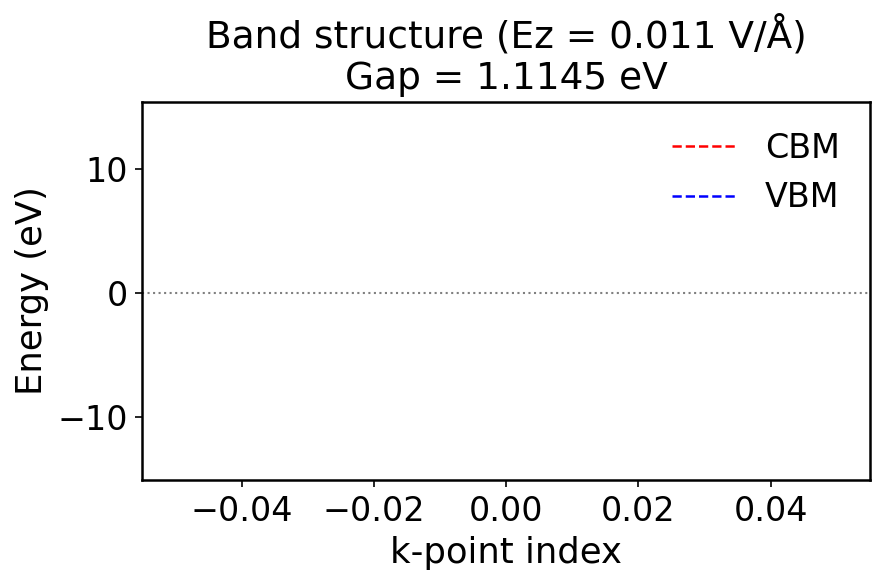

[2025-12-16 20:10:37] Ez=0.011 -> gap=1.114527 eV


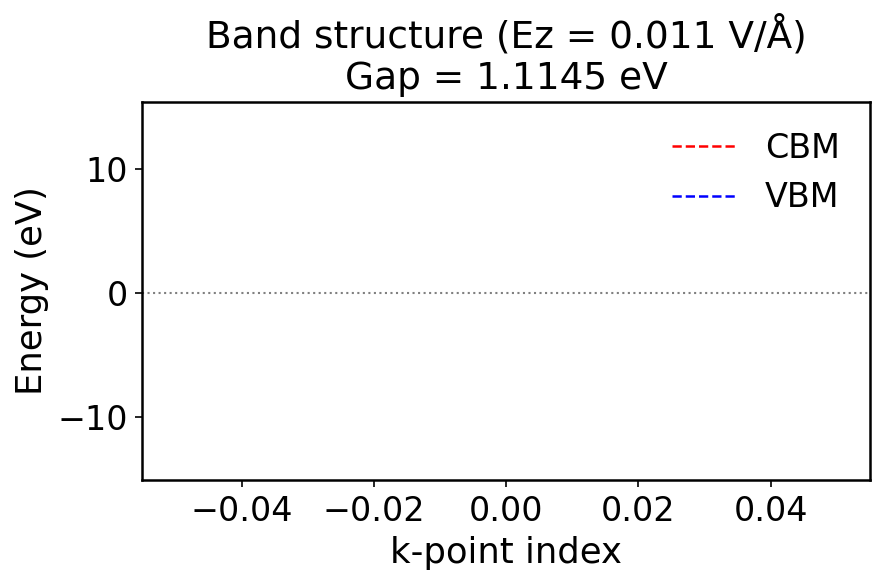

[2025-12-16 20:10:37] Ez=0.011 -> gap=1.114527 eV


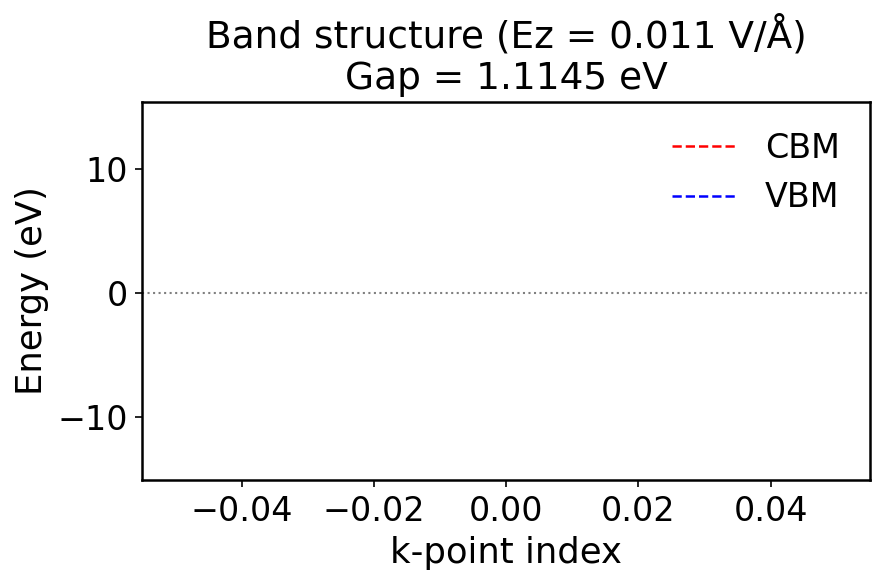

[2025-12-16 20:10:37] Ez=0.011 -> gap=1.114527 eV


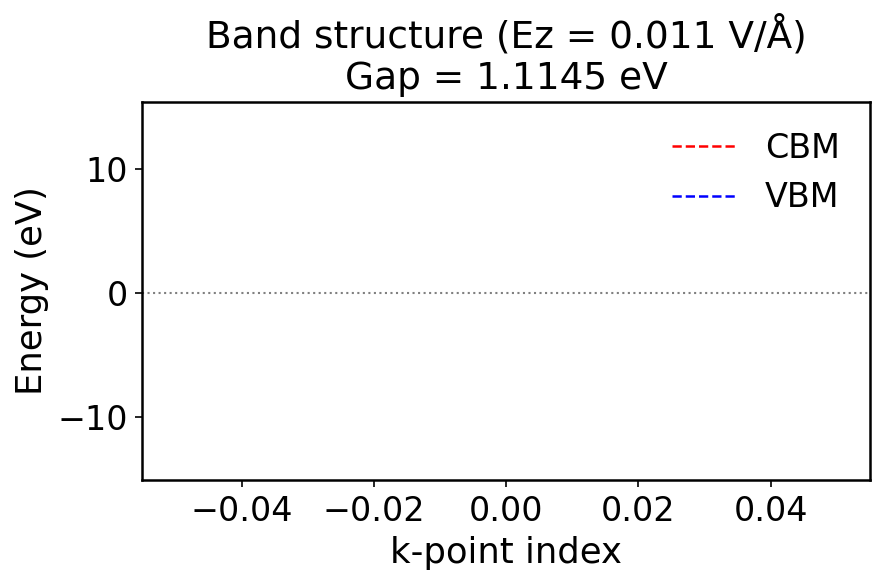

[2025-12-16 20:10:37] Ez=0.011 -> gap=1.114527 eV


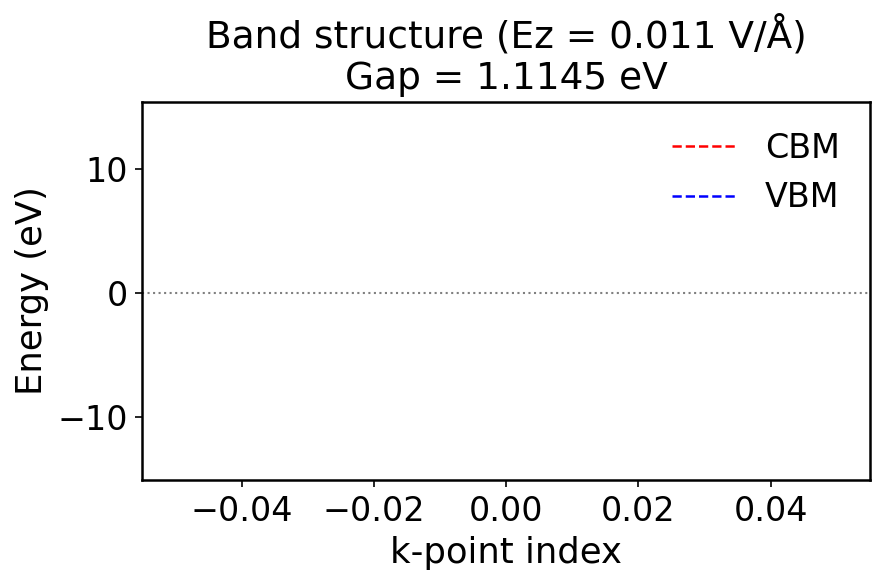

[2025-12-16 20:10:37] Ez=0.011 -> gap=1.114527 eV


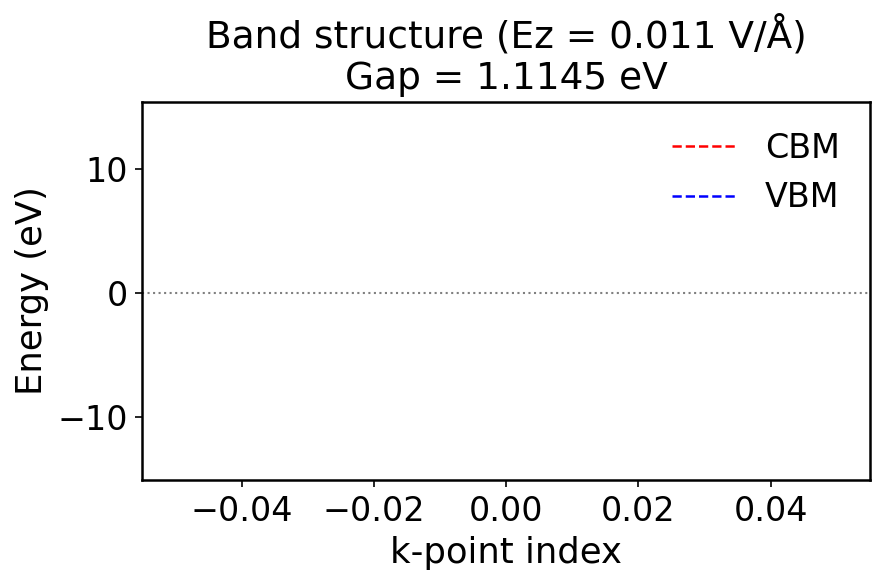

[2025-12-16 20:10:37] Ez=0.012 -> gap=1.185551 eV


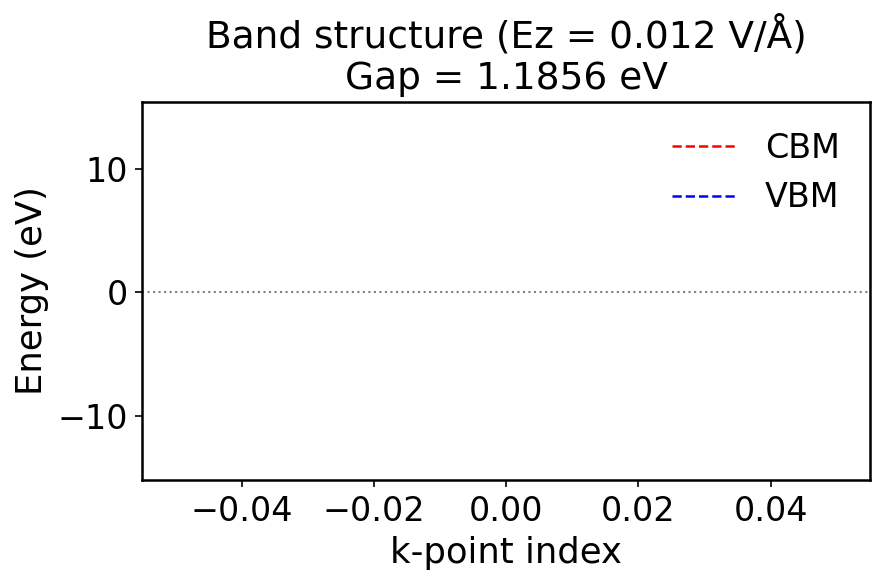

[2025-12-16 20:10:38] Ez=0.013 -> gap=1.271058 eV


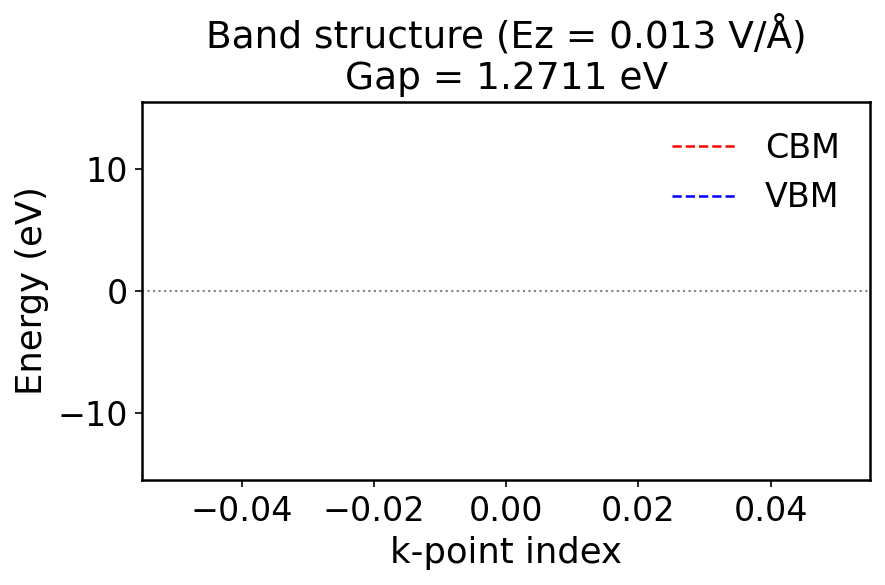

[2025-12-16 20:10:38] Ez=0.013 -> gap=1.271058 eV


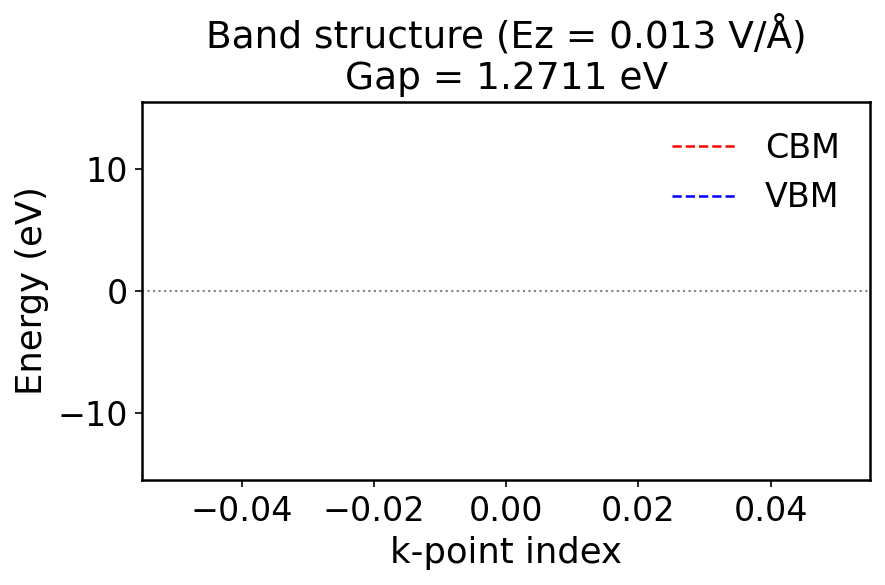

[2025-12-16 20:10:38] Ez=0.014 -> gap=1.307008 eV


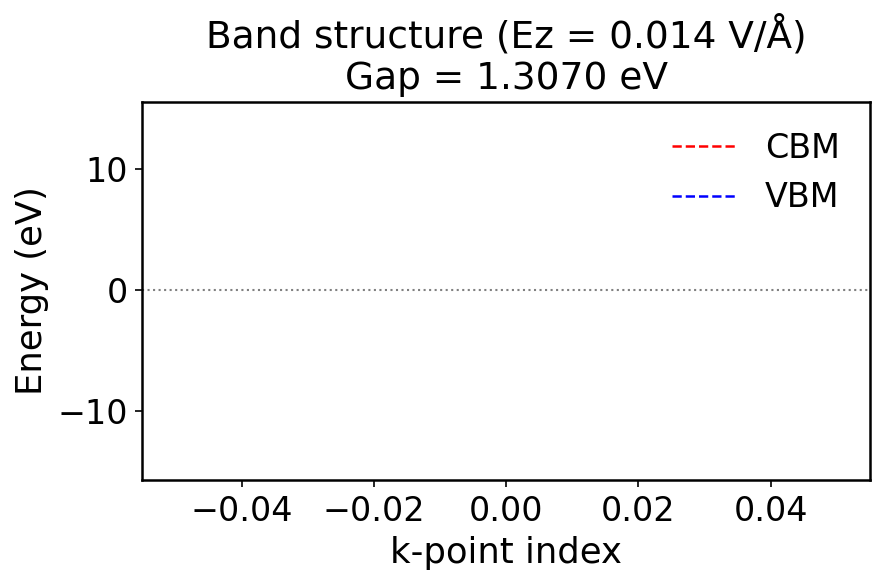

[2025-12-16 20:10:38] Ez=0.016 -> gap=1.410963 eV


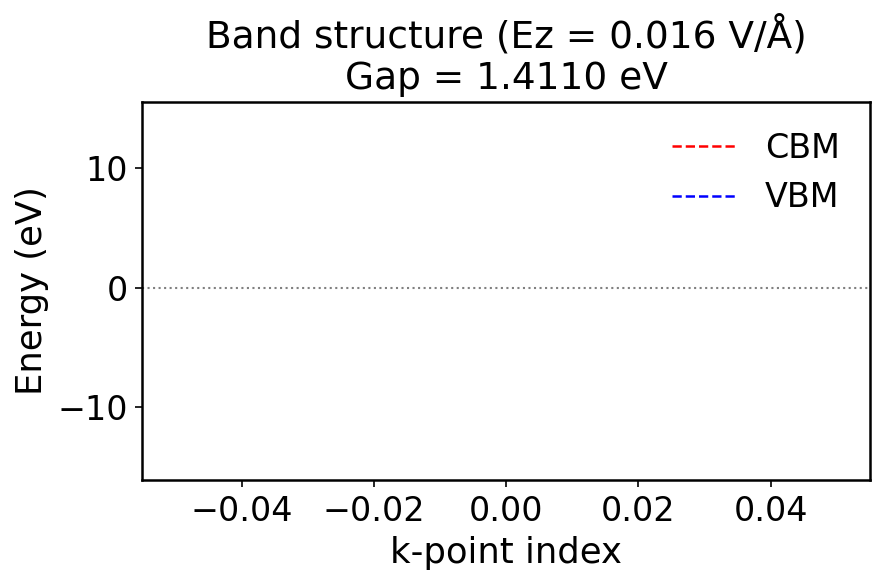

[2025-12-16 20:10:38] Ez=0.017 -> gap=1.438648 eV


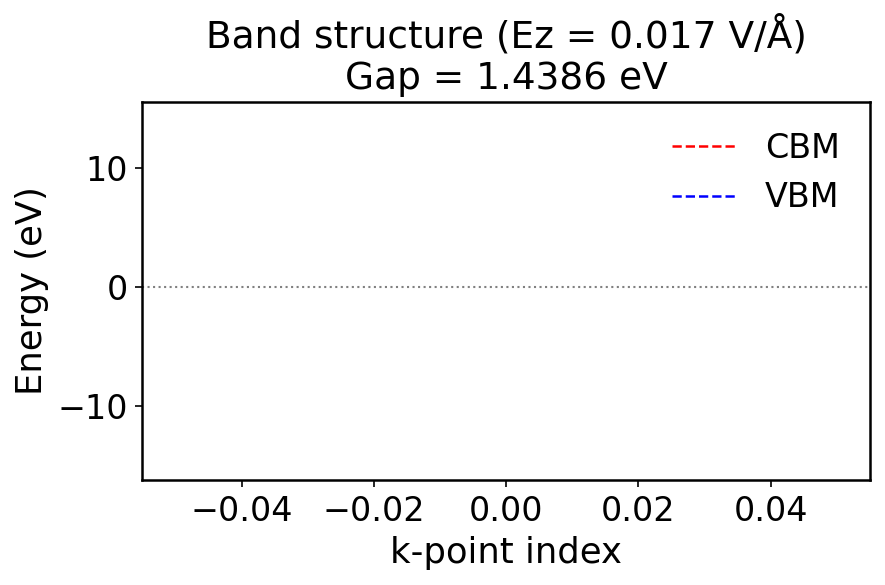

[2025-12-16 20:10:38] Ez=0.017 -> gap=1.438648 eV


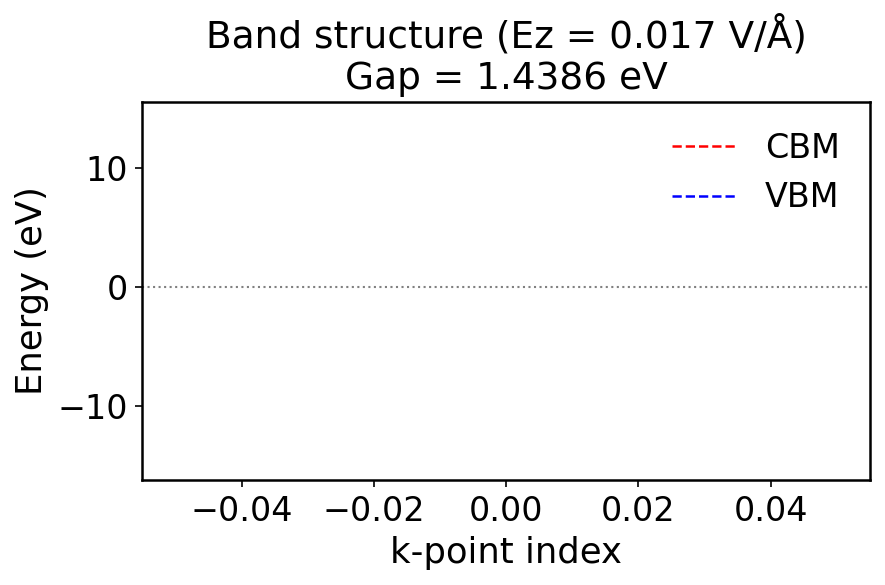

[2025-12-16 20:10:38] Ez=0.018 -> gap=1.491919 eV


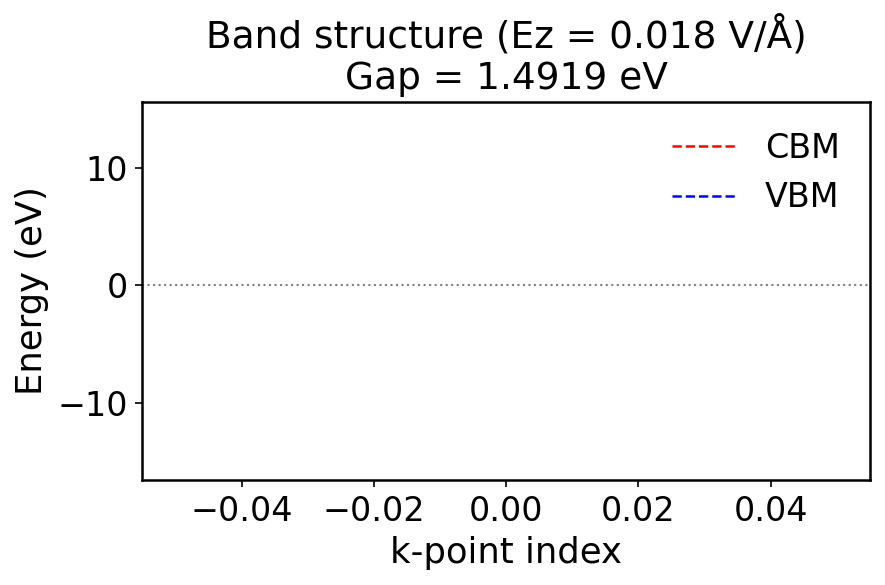

[2025-12-16 20:10:39] Ez=0.019 -> gap=1.524353 eV


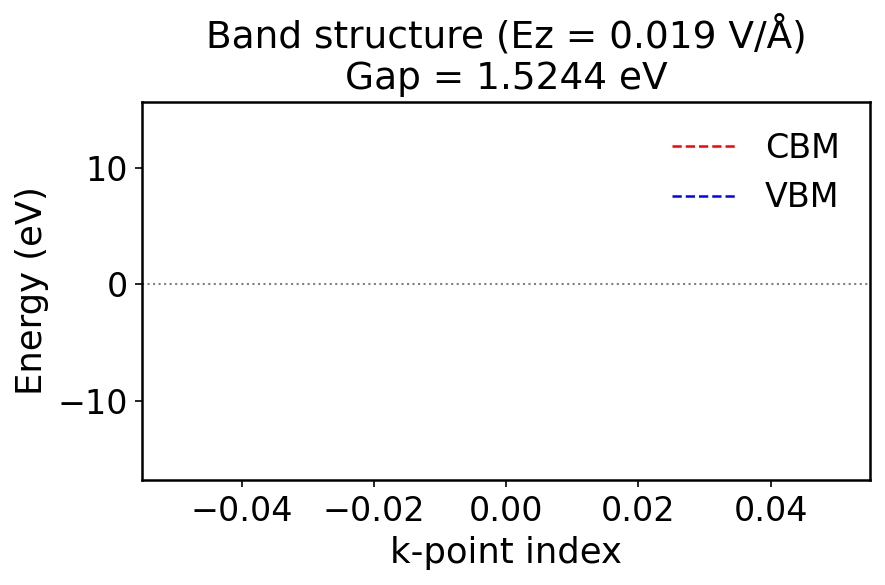

[2025-12-16 20:10:39] Ez=0.020 -> gap=1.556615 eV


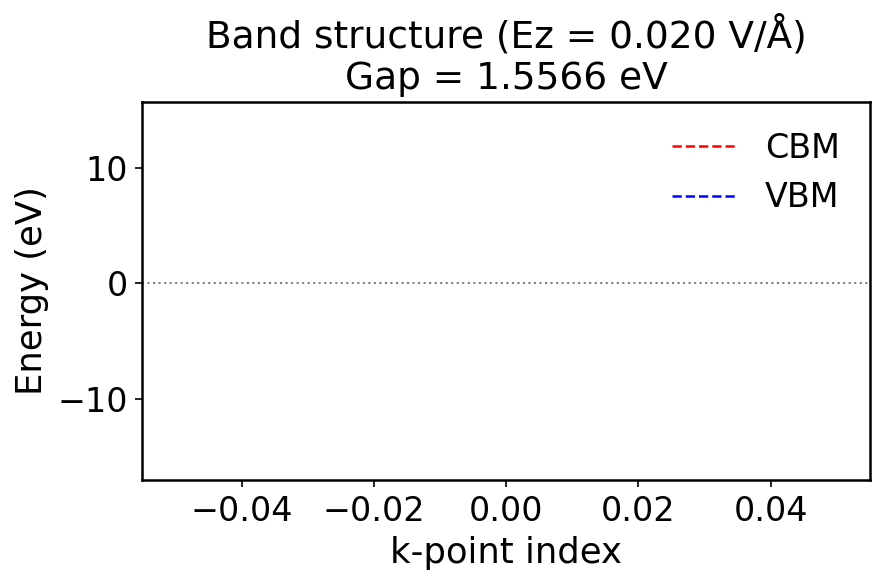

[2025-12-16 20:10:39] Ez=0.023 -> gap=1.571022 eV


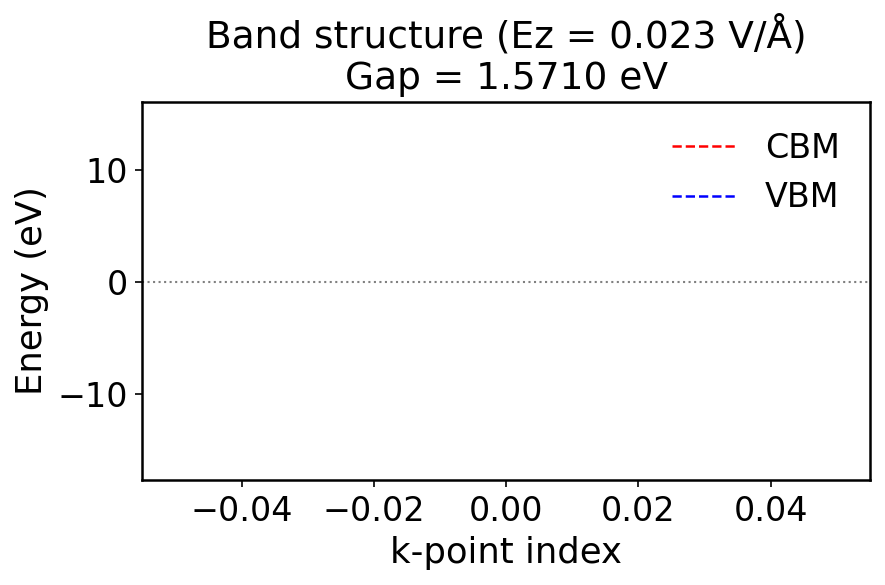

[2025-12-16 20:10:39] Ez=0.027 -> gap=1.398100 eV


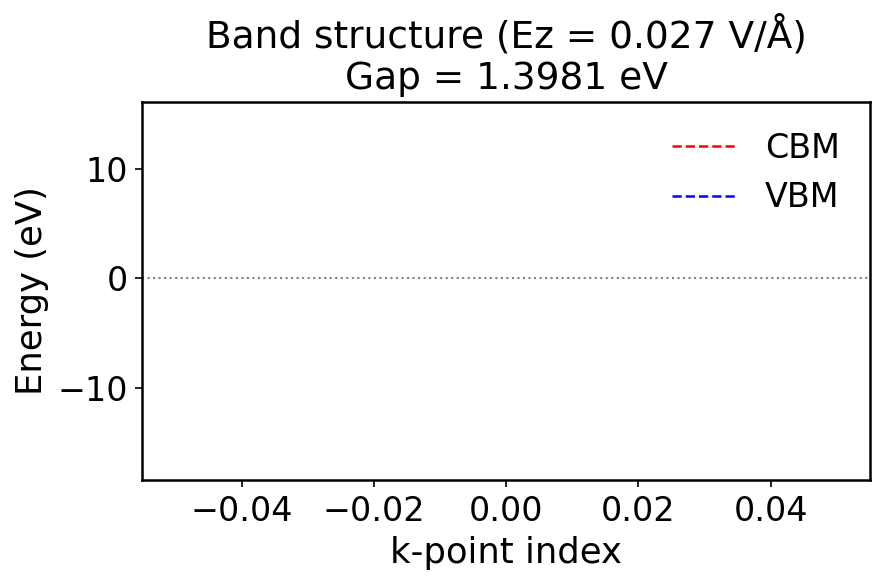

[2025-12-16 20:10:39] Ez=0.030 -> gap=9.275251 eV


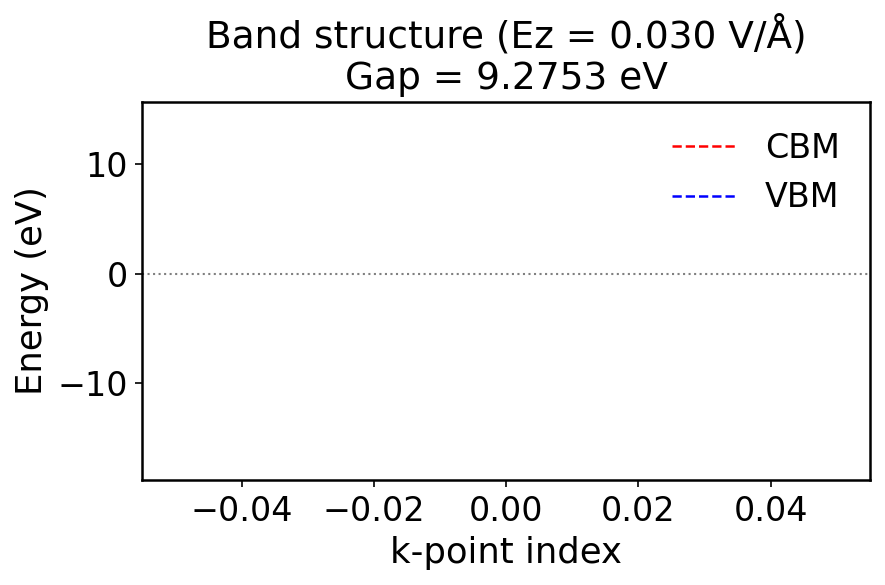

[2025-12-16 20:10:39] Ez=0.033 -> gap=9.543910 eV


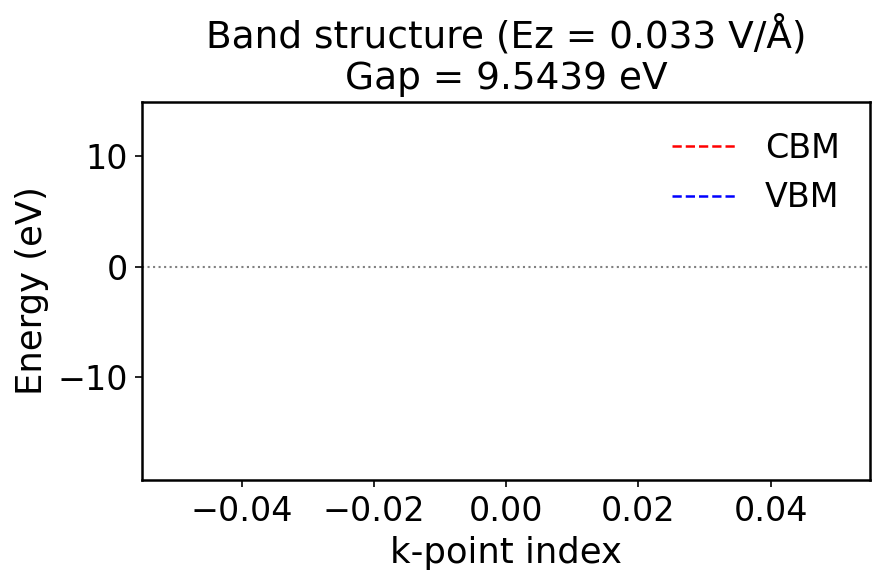

[2025-12-16 20:10:39] Ez=0.037 -> gap=9.690486 eV


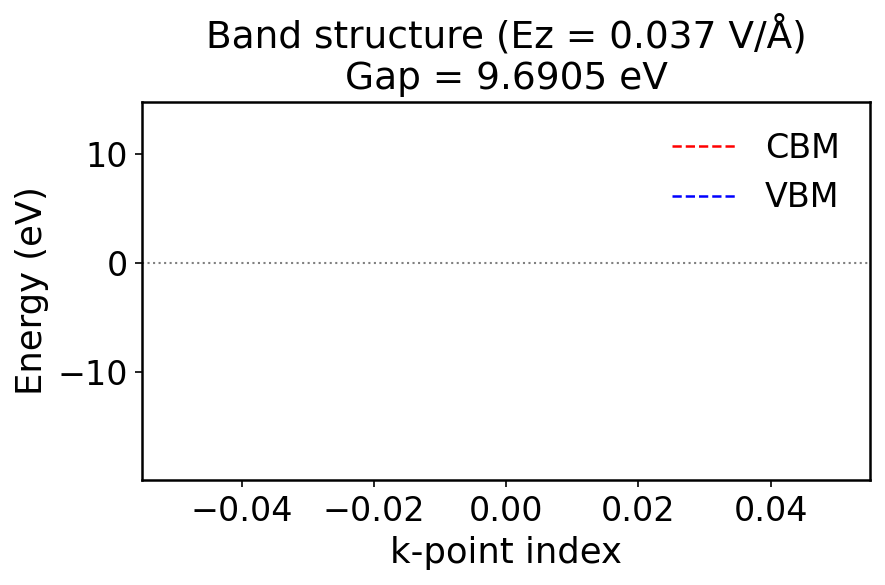

[2025-12-16 20:10:40] Ez=0.040 -> gap=9.792671 eV


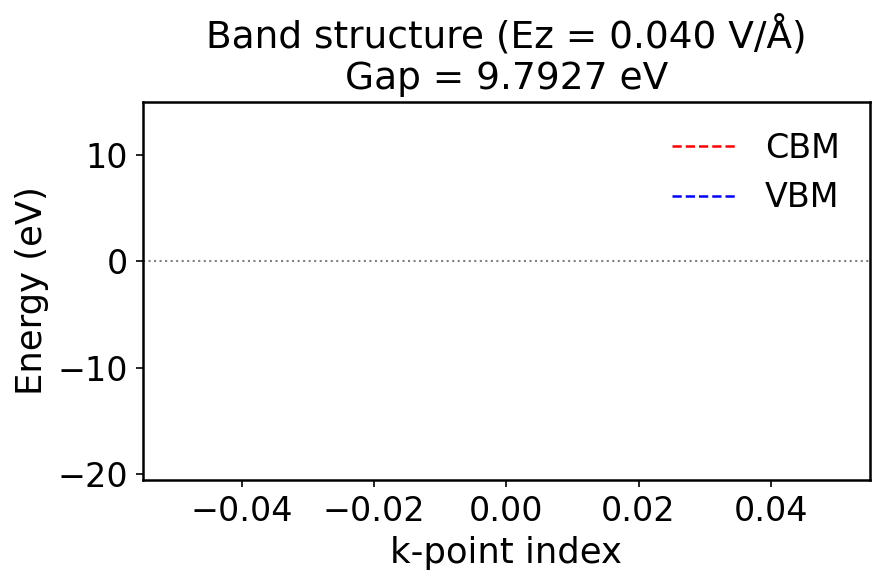

[2025-12-16 20:10:40] Ez=0.043 -> gap=9.875712 eV


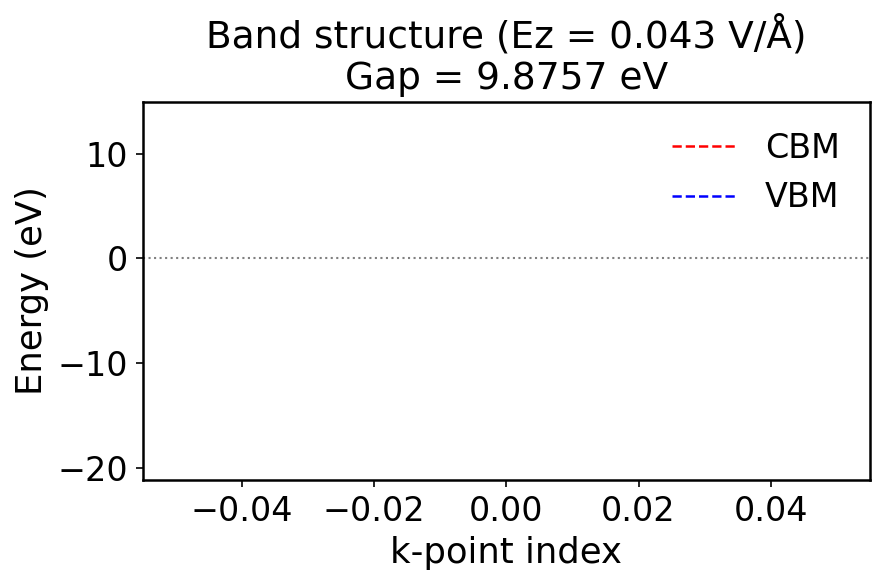

[2025-12-16 20:10:40] Ez=0.047 -> gap=9.995615 eV


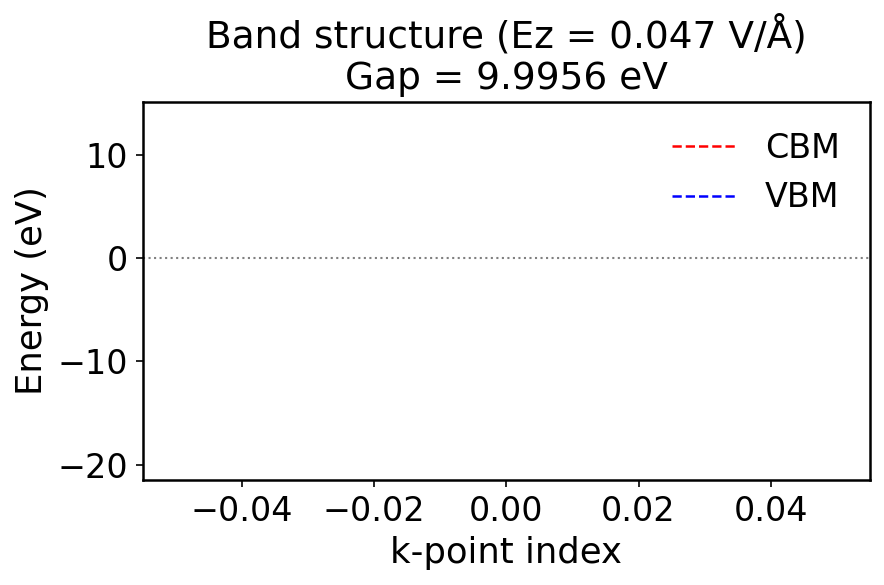

[2025-12-16 20:10:40] Ez=0.050 -> gap=10.054030 eV


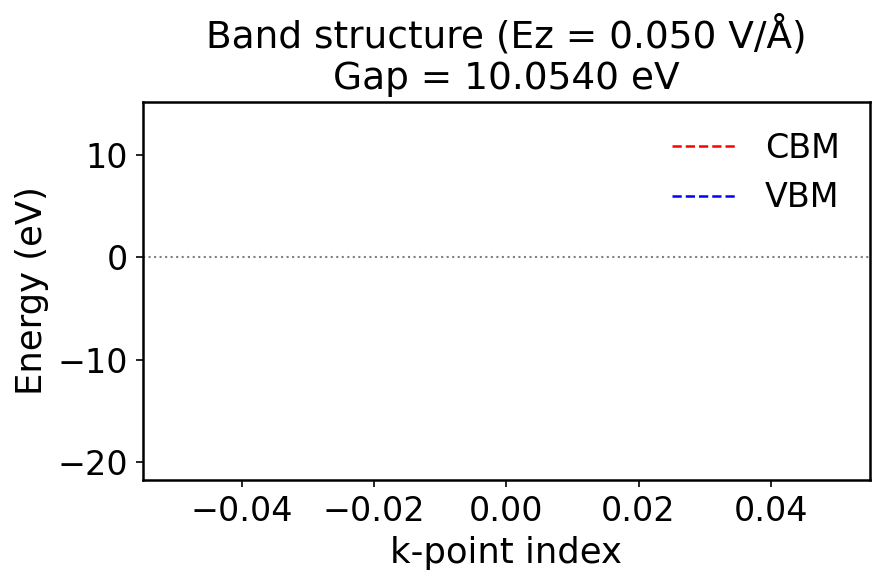

[2025-12-16 20:10:40] Ez=0.053 -> gap=10.060229 eV


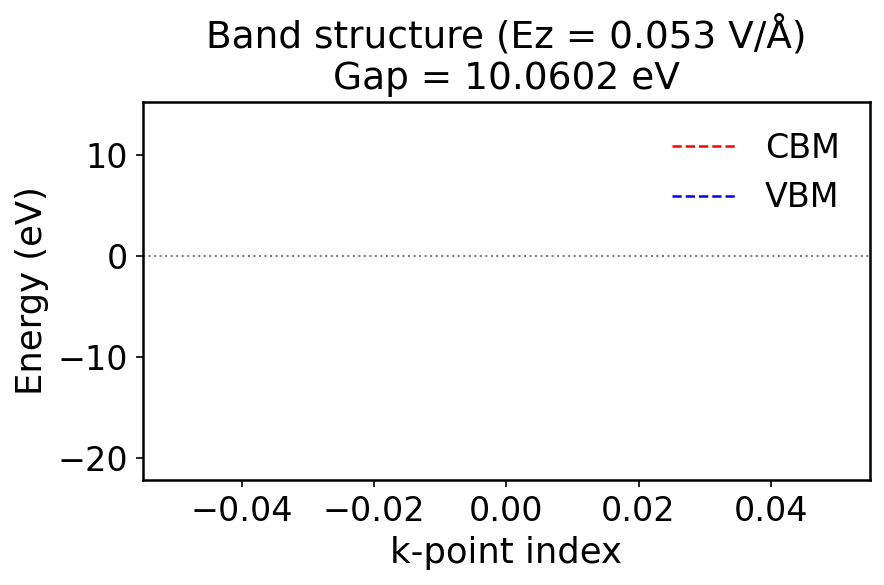

[2025-12-16 20:10:40] Ez=0.057 -> gap=10.044372 eV


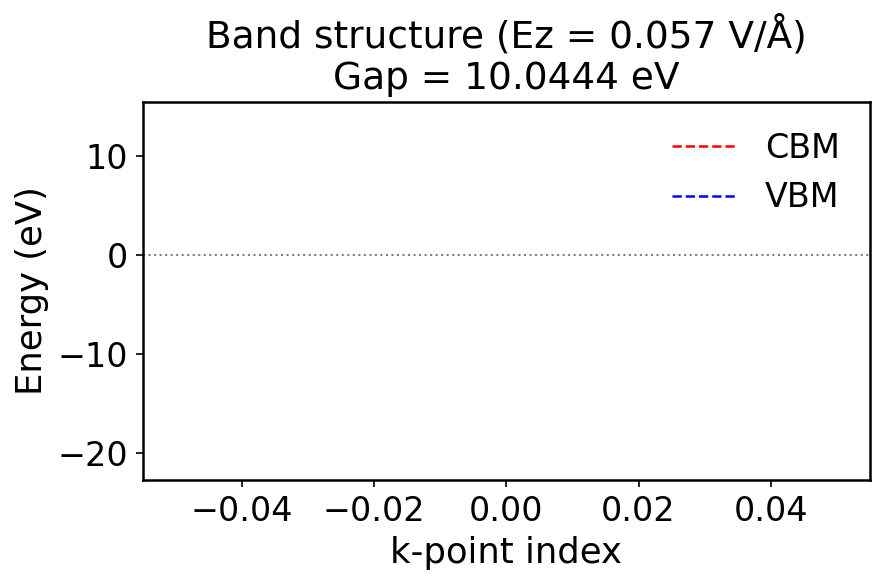

[2025-12-16 20:10:41] Saved band gaps to ../gpw/bandgaps_KZOOM.csv


In [29]:
import os
import numpy as np
import csv
from ase.dft.bandgap import bandgap

# Output CSV (simple and plot-friendly)
gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

results = []

fields_from_csv = np.array(fields_from_csv, dtype=object)
mask = fields_from_csv[:, 0].astype(float) > 0#< 0.1
fields_from_csv = fields_from_csv[mask]

# order by Ez
idx = np.argsort(fields_from_csv[:, 0].astype(float))
fields_from_csv = fields_from_csv[idx]

for Ez, gpw_Ez in fields_from_csv:
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz")

    if not os.path.exists(npz_Ez):
        log(f"K-zoom NPZ missing for Ez={Ez:.3f} — skipping gap")
        continue

    data = np.load(npz_Ez)
    E = data["E"]        # shape: (Nk, nbands), already shifted by EF

    # ---- band selection (as requested) ----
    # upper band closest to 0
    upper_mask = E > 0
    lower_mask = E < 0

    if not np.any(upper_mask) or not np.any(lower_mask):
        log(f"No valid upper/lower bands for Ez={Ez:.3f}")
        continue

    upper_band = np.min(E, axis=1, where=upper_mask, initial=np.inf)
    lower_band = np.max(E, axis=1, where=lower_mask, initial=-np.inf)

    # bandgap = minimum vertical separation
    gap_k = upper_band - lower_band
    gap = np.min(gap_k)

    results.append((Ez, gap))
    log(f"Ez={Ez:.3f} -> gap={gap:.6f} eV")
    # ---- plot bands ----
    Nk, nbands = E.shape
    k = np.arange(Nk)

    plt.figure(figsize=(6, 4))

    # plot all bands
    for b in range(nbands):
        plt.plot(k, E[:, b], color="black", linewidth=0.8)

    # highlight band edges used for the gap
    plt.plot(k, upper_band, color="red", linestyle="--", linewidth=1.2, label="CBM")
    plt.plot(k, lower_band, color="blue", linestyle="--", linewidth=1.2, label="VBM")

    # Fermi level
    plt.axhline(0.0, color="gray", linestyle=":", linewidth=1)

    plt.title(f"Band structure (Ez = {Ez:.3f} V/Å)\nGap = {gap:.4f} eV")
    plt.xlabel("k-point index")
    plt.ylabel("Energy (eV)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---- save to CSV ----
with open(gap_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Ez", "bandgap_eV"])
    writer.writerows(results)

log(f"Saved band gaps to {gap_csv}")


array([ True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

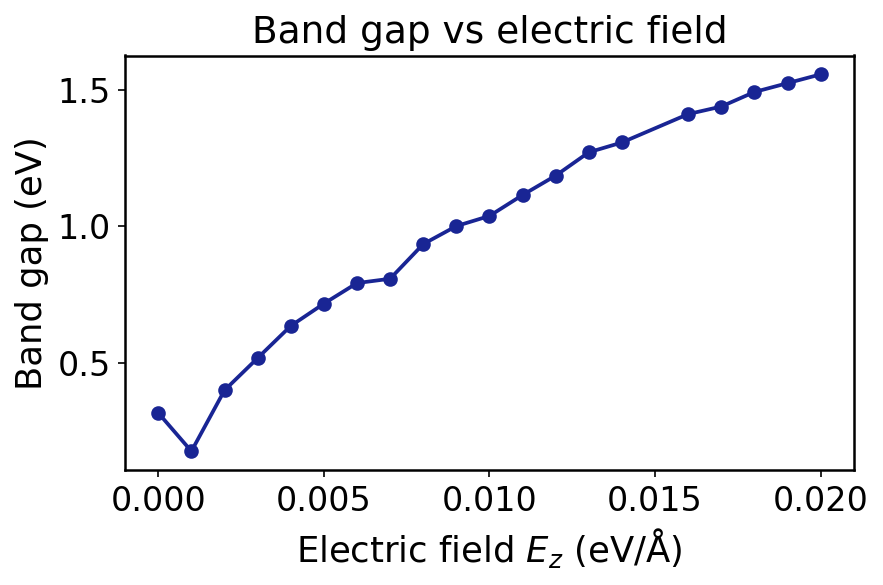

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
from collections import defaultdict
from common.mpl_style import set_mpl_style

# ----------------------------------
# Styling
# ----------------------------------
set_mpl_style()

# ----------------------------------
# Input
# ----------------------------------
gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

Ez_vals = []
gaps = []

with open(gap_csv, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        Ez_vals.append(float(row["Ez"]))
        gaps.append(float(row["bandgap_eV"]))

Ez_vals = np.array(Ez_vals)
gaps = np.array(gaps)

# ----------------------------------
# Filter field range
# ----------------------------------
mask = Ez_vals < 0.023
Ez_vals = Ez_vals[mask]
gaps = gaps[mask]

# ----------------------------------
# Group Ez by rounding to 3 decimals
# ----------------------------------
groups = defaultdict(list)

for Ez, gap in zip(Ez_vals, gaps):
    Ez_key = np.round(Ez, 3)
    groups[Ez_key].append(gap)

# ----------------------------------
# Build grouped arrays
# (use mean gap per field)
# ----------------------------------
Ez_grouped = np.array(sorted(groups.keys()))
gaps_grouped = np.array([
    np.mean(groups[Ez]) for Ez in Ez_grouped
])

# ----------------------------------
# Plot
# ----------------------------------
plt.figure(figsize=(6, 4))
plt.plot(Ez_grouped, gaps_grouped, marker="o", color='#192594')
plt.xlabel("Electric field $E_z$ (eV/Å)")
plt.ylabel("Band gap (eV)")
plt.title("Band gap vs electric field")

from matplotlib.ticker import FormatStrFormatter
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))

plt.grid(True)
plt.tight_layout()
plt.savefig('../data/band_gap_vs_field.pdf')
plt.show()



In [133]:
idx = np.argsort(Ez_vals)
idx = idx[Ez_vals < 0.03]

Ez_vals[idx]

array([0.      , 0.000202, 0.000404, 0.000606, 0.000808, 0.00101 ,
       0.001212, 0.001414, 0.001616, 0.002   , 0.00202 , 0.002222,
       0.002424, 0.0025  , 0.002626, 0.002828, 0.00303 , 0.003232,
       0.003434, 0.003636, 0.003838, 0.00404 , 0.004242, 0.004444,
       0.004646, 0.004848, 0.005   , 0.005051, 0.005253, 0.005455,
       0.005657, 0.005859, 0.006061, 0.006263, 0.006465, 0.006667,
       0.006869, 0.007071, 0.007273, 0.007475, 0.0075  , 0.007677,
       0.007879, 0.008081, 0.008283, 0.008485, 0.008687, 0.008889,
       0.009091, 0.009293, 0.009495, 0.009697, 0.009899, 0.01    ,
       0.010101, 0.010303, 0.010505, 0.010707, 0.010909, 0.011   ,
       0.011111, 0.011313, 0.012   , 0.0125  , 0.013   , 0.014   ,
       0.015   , 0.016   , 0.017   , 0.018   , 0.019   , 0.02    ])

# Load saved full-path band data and PLOT for each field


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import numpy as np

fields_from_csv = fields_from_csv[fields_from_csv[:, 0]< 0.022]
# Convert to array for easy handling
fields_arr = np.array(fields_from_csv, dtype=object)

# Round Ez to 3 decimals (string-safe and filename-consistent)
Ez_rounded = np.round(fields_arr[:, 0].astype(float), 3)

# Build unique list, keeping first occurrence
_, unique_idx = np.unique(Ez_rounded, return_index=True)

fields_from_csv = np.array(
    [(Ez_rounded[i], fields_arr[i, 1]) for i in sorted(unique_idx)],
    dtype=object
)

gif_path = os.path.join(out_dir, "bands_KZOOM_vs_field.gif")
fps = 4

# Ensure sorted by Ez
fields_arr = np.array(fields_from_csv, dtype=object)
idx = np.argsort(fields_arr[:, 0].astype(float))
fields_sorted = fields_arr[idx]

frames = []
colors = ["#7A1F1F", "#B23A48",  "#1C6E8C", "#0B3C5D",]  # dark → lighter red


for _Ez, _gpw in fields_sorted:
    _Ez = float(_Ez)
    _npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz")
    if not os.path.exists(_npz_Ez):
        log(f"Full-path NPZ not found for Ez={_Ez:.3f}: {_npz_Ez} — skipping frame")
        continue

    _data = np.load(_npz_Ez)
    _x = _data["x"]
    _E = _data["E"]

    # EXACT same plotting settings
    fig = plt.figure(figsize=(6, 4))

    # pi_bands_index, pi_bands_vals = [], []
    # for n in range(_E.shape[1]):
    #     if np.any((_E[:, n] > -1) & (_E[:, n] < 1)):
    #         pi_bands_index.append(n)
    #         pi_bands_vals.append(_E[5, n])
    #
    # ordered_indexes = np.argsort(pi_bands_vals)
    # ordered_ns = np.array(pi_bands_index)[ordered_indexes]


    for n in range(_E.shape[1]):
        if np.any((_E[:, n] > -1) & (_E[:, n] < 1)):
            plt.plot(x, _E[:, n], lw=3)
    plt.ylim(-1, 1)
    plt.xlabel("k")
    plt.ylabel(r"$E - E_F$ (eV)")
    plt.title(f"Energy bands at Ez={_Ez:.3f} eV/Å")
    plt.tight_layout()

    # ---- backend-safe frame extraction ----
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    frames.append(frame)

    plt.close(fig)

# write gif
if len(frames) == 0:
    log("No frames collected — GIF not written.")
else:
    imageio.mimsave(gif_path, frames, fps=fps)
    log(f"Saved GIF to {gif_path}")


[2025-12-16 19:41:04] Saved GIF to ../gpw/bands_KZOOM_vs_field.gif


for  0.001
plotting   [[-1.35895761e+01 -1.34336853e+01 -1.26722013e+01 -1.25281107e+01
  -9.70259975e+00 -9.55950750e+00 -1.45618053e+00 -1.07230163e+00
   9.06011540e-01  1.07248067e+00  1.08311867e+01  1.12255830e+01
   1.17058099e+01  1.21500020e+01  1.22672749e+01  1.25672400e+01]
 [-1.35508432e+01 -1.33951017e+01 -1.26486647e+01 -1.25047228e+01
  -9.79549653e+00 -9.65252767e+00 -1.40198295e+00 -1.01881162e+00
   8.61967636e-01  1.03188699e+00  1.07966134e+01  1.12108678e+01
   1.18141087e+01  1.21977615e+01  1.24063407e+01  1.26434570e+01]
 [-1.35112693e+01 -1.33556820e+01 -1.26262829e+01 -1.24824917e+01
  -9.88656250e+00 -9.74380663e+00 -1.34668857e+00 -9.64270188e-01
   8.15292848e-01  9.90338839e-01  1.07719945e+01  1.11846852e+01
   1.19183676e+01  1.22512962e+01  1.25476262e+01  1.27270288e+01]
 [-1.34708598e+01 -1.33154308e+01 -1.26053516e+01 -1.24617073e+01
  -9.97545992e+00 -9.83301604e+00 -1.29031231e+00 -9.08699670e-01
   7.66037221e-01  9.47790837e-01  1.07489439e+01  

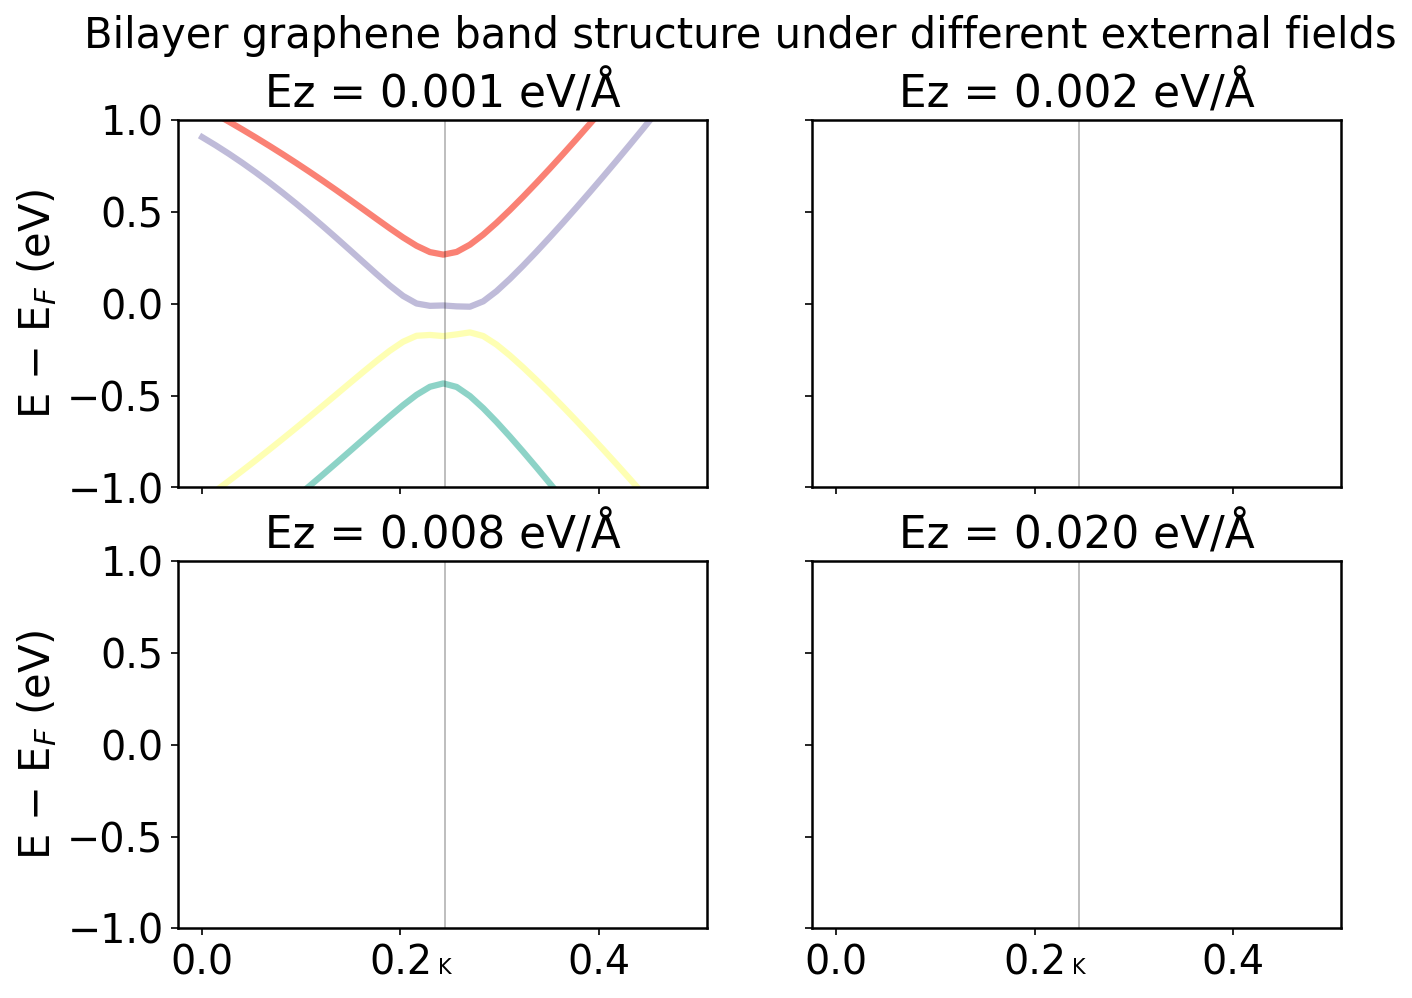

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from common.mpl_style import set_mpl_style

# ----------------------------------
# Assumptions
# ----------------------------------
# fields_from_csv: array-like of (Ez, gpw_path)
# out_dir: directory containing the *_bands_KZOOM.npz files
# Each NPZ contains arrays: x, E
# ----------------------------------
set_mpl_style(linewidth=5, fontsize=20)
# Filter and clean fields (same logic as your GIF code)
fields_from_csv = fields_from_csv[fields_from_csv[:, 0] < 0.022]
fields_arr = np.array(fields_from_csv, dtype=object)

Ez_vals = np.round(fields_arr[:, 0].astype(float), 3)

# keep unique Ez (first occurrence)
_, unique_idx = np.unique(Ez_vals, return_index=True)
fields_arr = np.array(
    [(Ez_vals[i], fields_arr[i, 1]) for i in sorted(unique_idx)],
    dtype=object
)

# sort by field
idx = np.argsort(fields_arr[:, 0].astype(float))
fields_sorted = fields_arr[idx]

Ez_sorted = fields_sorted[:, 0].astype(float)

# ----------------------------------
# Choose target fields
# ----------------------------------
targets = [0.0, 0.002, 0.008, 0.02]
chosen = []

for t in targets:
    i = np.argmin(np.abs(Ez_sorted - t))
    chosen.append(fields_sorted[i])

# ----------------------------------
# Plot
# ----------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

#valence_colors = []      # dark → lighter blue
colors = ["#7A1F1F", "#B23A48",  "#1C6E8C", "#0B3C5D",]  # dark → lighter red

for ax, (_Ez, _gpw) in zip(axes, chosen):
    _Ez = float(_Ez)
    npz_path = os.path.join(
        out_dir,
        f"ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz"
    )

    if not os.path.exists(npz_path):
        ax.set_title(f"Ez = {_Ez:.3f} eV/Å\n(MISSING)")
        continue

    data = np.load(npz_path)
    x = data["x"]
    E = data["E"]

    pi_bands_index, pi_bands_vals = [], []
    for n in range(E.shape[1]):
        if np.any((E[:, n] > -1) & (E[:, n] < 1)):
            pi_bands_index.append(n)
            pi_bands_vals.append(E[5, n])

    ordered_indexes = np.argsort(pi_bands_vals)
    ordered_ns = np.array(pi_bands_index)[ordered_indexes]
   # print(ordered_ns)
    print('for ', _Ez)
    for n in range(E.shape[1]):
        if np.any((E[:, n] > -1) & (E[:, n] < 1)):
            print('plotting  ', E[:])

            ax.plot(x, E[:, n], lw=3)#, color=colors[np.argmax(ordered_ns==n)])

    ax.set_title(f"Ez = {_Ez:.3f} eV/Å")

# ----------------------------------
# Common formatting
# ----------------------------------

for ax in axes:
    ax.set_ylim(-1.0, 1.0)
    ax.grid(False)

K_pos = 0.245

i = 0
for ax in axes:
    ax.axvline(K_pos, color="k", lw=0.8, alpha=0.3)  # optional, but useful
    if i >= 2:
        ax.text(
            K_pos,
            -0.08,
            "K",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top"
        )
    i += 1


#axes[2].set_xlabel("k (cumulative path)")
#axes[3].set_xlabel("k (cumulative path)")
axes[0].set_ylabel("E − E$_F$ (eV)")
axes[2].set_ylabel("E − E$_F$ (eV)")

fig.suptitle(
    "Bilayer graphene band structure under different external fields",
    fontsize=20
)

plt.savefig('../data/different_fields.pdf')
#plt.tight_layout(rect=[0, 0, 1, 0.94])
#plt.show()


In [16]:
fields_from_csv

array([[np.float64(0.001), '../gpw/ab_gate_plane_A0.001.gpw'],
       [np.float64(0.002), '../gpw/ab_gate_plane_A0.002.gpw'],
       [np.float64(0.003), '../gpw/ab_gate_plane_A0.003.gpw'],
       [np.float64(0.004), '../gpw/ab_gate_plane_A0.004.gpw'],
       [np.float64(0.005), '../gpw/ab_gate_plane_A0.005.gpw'],
       [np.float64(0.006), '../gpw/ab_gate_plane_A0.006.gpw'],
       [np.float64(0.007), '../gpw/ab_gate_plane_A0.007.gpw'],
       [np.float64(0.008), '../gpw/ab_gate_plane_A0.008.gpw'],
       [np.float64(0.009), '../gpw/ab_gate_plane_A0.009.gpw'],
       [np.float64(0.01), '../gpw/ab_gate_plane_A0.010.gpw'],
       [np.float64(0.011), '../gpw/ab_gate_plane_A0.011.gpw'],
       [np.float64(0.012), '../gpw/ab_gate_plane_A0.012.gpw'],
       [np.float64(0.013), '../gpw/ab_gate_plane_A0.013.gpw'],
       [np.float64(0.014), '../gpw/ab_gate_plane_A0.014.gpw'],
       [np.float64(0.016), '../gpw/ab_gate_plane_A0.016.gpw'],
       [np.float64(0.017), '../gpw/ab_gate_plane_A0.017.

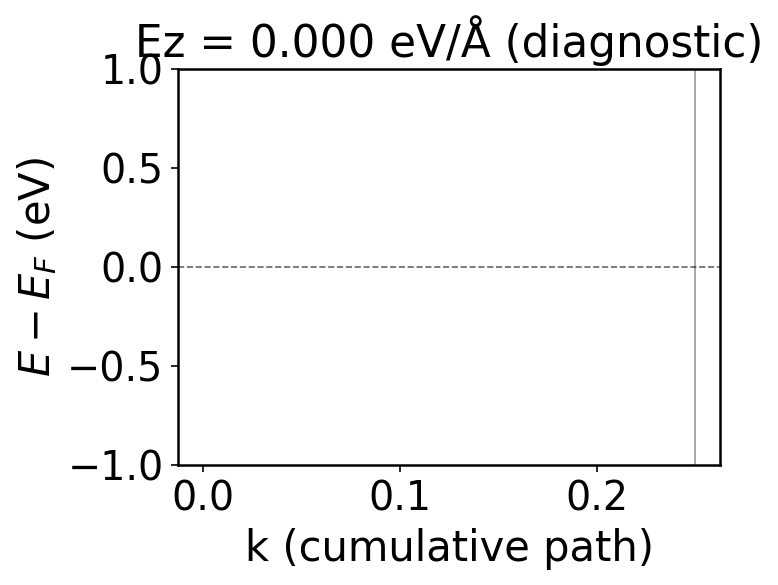

[2025-12-16 20:03:04] Ez=0.000 -> gap=0.316070 eV at k-index 0 (VBM=-0.023225, CBM=0.292845)
[2025-12-16 20:03:04] Ez=0.001 (group 0.001) -> gap=0.175656 eV
[2025-12-16 20:03:04] Ez_group=0.001 -> gap(MAX over 1) = 0.175656 eV
[2025-12-16 20:03:04] Ez=0.002 (group 0.002) -> gap=0.399021 eV
[2025-12-16 20:03:04] Ez_group=0.002 -> gap(MAX over 1) = 0.399021 eV
[2025-12-16 20:03:04] Ez=0.003 (group 0.003) -> gap=0.517056 eV
[2025-12-16 20:03:04] Ez_group=0.003 -> gap(MAX over 1) = 0.517056 eV
[2025-12-16 20:03:04] Ez=0.004 (group 0.004) -> gap=0.634824 eV
[2025-12-16 20:03:04] Ez_group=0.004 -> gap(MAX over 1) = 0.634824 eV
[2025-12-16 20:03:04] Ez=0.005 (group 0.005) -> gap=0.716461 eV
[2025-12-16 20:03:04] Ez_group=0.005 -> gap(MAX over 1) = 0.716461 eV
[2025-12-16 20:03:04] Ez=0.006 (group 0.006) -> gap=0.791825 eV
[2025-12-16 20:03:04] Ez_group=0.006 -> gap(MAX over 1) = 0.791825 eV
[2025-12-16 20:03:04] Ez=0.007 (group 0.007) -> gap=0.807647 eV
[2025-12-16 20:03:04] Ez_group=0.007 ->

In [17]:
import os
import numpy as np
import csv
from collections import defaultdict

# Output CSV
gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

results = []

fields_from_csv = np.array(fields_from_csv, dtype=object)

# keep only Ez > 0 (as in your original code)
mask = fields_from_csv[:, 0].astype(float) > 0
fields_from_csv = fields_from_csv[mask]


# ----------------------------------
# Explicitly include Ez = 0 if present
# ----------------------------------
Ez_zero = 0.0
npz_zero = os.path.join(out_dir, "ab_gate_plane_A0.000_bands_KZOOM.npz")

zero_gap = None

if os.path.exists(npz_zero):
    data = np.load(npz_zero)
    E = data["E"]      # (Nk, nbands), already shifted by EF
    x = data["x"]      # cumulative k-path

    # -------------------------------
    # DIAGNOSTIC PLOT
    # -------------------------------
    import matplotlib.pyplot as plt

    plt.figure(figsize=(5, 4))
    for n in range(E.shape[1]):
        plt.plot(x, E[:, n], lw=1.2)

    plt.axhline(0.0, color="k", ls="--", lw=0.8, alpha=0.6)
    plt.axvline(0.25, color="k", lw=0.8, alpha=0.4)  # K point, if applicable

    plt.ylim(-1.0, 1.0)
    plt.xlabel("k (cumulative path)")
    plt.ylabel(r"$E - E_F$ (eV)")
    plt.title("Ez = 0.000 eV/Å (diagnostic)")
    plt.tight_layout()
    plt.show()

    # -------------------------------
    # GAP COMPUTATION (unchanged)
    # -------------------------------
    upper_mask = E > 0
    lower_mask = E < 0

    if np.any(upper_mask) and np.any(lower_mask):
        upper_band = np.min(E, axis=1, where=upper_mask, initial=np.inf)
        lower_band = np.max(E, axis=1, where=lower_mask, initial=-np.inf)

        gap_k = upper_band - lower_band
        ik = np.argmin(gap_k)
        zero_gap = float(gap_k[ik])

        log(
            f"Ez=0.000 -> gap={zero_gap:.6f} eV "
            f"at k-index {ik} "
            f"(VBM={lower_band[ik]:.6f}, CBM={upper_band[ik]:.6f})"
        )
    else:
        log("Ez=0.000 present but no valid upper/lower bands")
else:
    log("Ez=0.000 NPZ not found")


# ----------------------------------
# Define rounded Ez (group key)
# ----------------------------------
Ez_rounded = np.round(fields_from_csv[:, 0].astype(float), 3)
if zero_gap is not None:
    results.insert(0, (0.000, zero_gap))
# ----------------------------------
# Group GPW/NPZ files by Ez_rounded
# ----------------------------------
groups = defaultdict(list)
for (Ez, gpw_Ez), Ez_r in zip(fields_from_csv, Ez_rounded):
    groups[Ez_r].append(float(Ez))

# ----------------------------------
# Loop over grouped fields
# ----------------------------------
for Ez_r in sorted(groups.keys()):

    gaps_this_group = []

    for Ez in groups[Ez_r]:
        npz_Ez = os.path.join(
            out_dir,
            f"ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz"
        )

        if not os.path.exists(npz_Ez):
            log(f"K-zoom NPZ missing for Ez={Ez:.3f} — skipping")
            continue

        data = np.load(npz_Ez)
        E = data["E"]  # (Nk, nbands), already shifted by EF

        # ----------------------------------
        # Gap computation (unchanged logic)
        # ----------------------------------
        upper_mask = E > 0
        lower_mask = E < 0

        if not np.any(upper_mask) or not np.any(lower_mask):
            log(f"No valid upper/lower bands for Ez={Ez:.3f}")
            continue

        upper_band = np.min(E, axis=1, where=upper_mask, initial=np.inf)
        lower_band = np.max(E, axis=1, where=lower_mask, initial=-np.inf)

        gap_k = upper_band - lower_band
        gap = np.min(gap_k)

        gaps_this_group.append(gap)

        log(f"Ez={Ez:.3f} (group {Ez_r:.3f}) -> gap={gap:.6f} eV")

         # ----------------------------------
        # One representative gap per Ez_rounded
        # (use MAX instead of mean)
        # ----------------------------------
        if len(gaps_this_group) > 0:
            gap_rep = float(np.max(gaps_this_group))

            results.append((Ez_r, gap_rep))

            log(
                f"Ez_group={Ez_r:.3f} "
                f"-> gap(MAX over {len(gaps_this_group)}) = {gap_rep:.6f} eV"
            )


# ----------------------------------
# Save CSV
# ----------------------------------
with open(gap_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Ez", "bandgap_eV"])
    writer.writerows(results)

log(f"Saved grouped band gaps to {gap_csv}")


In [76]:
Ez_sorted

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.016, 0.017, 0.018,
       0.019, 0.02 ])

In [209]:
fields_arr

array([['0.0', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000202', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000404', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000606', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.000808', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.00101', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001212', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001414', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001616', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.001818', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.00202', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002222', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002424', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.0025', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.002626', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.002828', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.00303', '../gpw/ab_gate_plane_A0.003.gpw'],
     